# **About Dataset**
## **1. Context**

It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

## **2. Content**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

# **About this notebook**
## **1. Overall**
- In this section, we load and explore the dataset at a high level. We examine the structure of the data, check for missing values, and understand the class distribution (fraudulent vs. legitimate transactions). The dataset contains 284,807 transactions with 492 fraud cases. Key insights include:

    + Dataset composition: 99.83% legitimate transactions, 0.17% fraudulent transactions
    + Features: 28 PCA-transformed features (V1-V28), plus Time and Amount columns
    + Target variable: Class (0 = legitimate, 1 = fraud)
- This imbalance means we can't simply train a standard classifier, as it would be biased toward predicting "not fraud" for everything.
## **2. EDA**
- Here we dive deeper into understanding the characteristics of fraudulent vs. legitimate transactions. We analyze:

    + Transaction amounts: How do fraud and legitimate transaction amounts differ?
    + Feature correlations: Which features are most strongly correlated with fraud?
    + Distribution patterns: Visualizations (boxplots, violin plots, heatmaps) reveal that fraud transactions tend to have different statistical properties than legitimate ones
- This exploratory phase helps us understand what signals in the data might help distinguish fraud from legitimate activity.

## **3. Preprocessing**
- Before training models, we prepare the data for machine learning:

    + Outlier detection: Using the IQR (Interquartile Range) method, we identify and remove extreme outliers that could distort model training
- This step is critical because outliers and unscaled features can negatively impact model performance.

## **4. Sampling methods**
- Since we have a severe class imbalance (0.17% fraud), we need techniques to balance the training data. This section compares five different sampling approaches:

    1. Random Under-Sampling (RUS): Randomly removes majority class samples to match minority class size
    2. NearMiss: Removes majority class samples that are closest to minority class samples
    3. Random Over-Sampling (ROS): Randomly duplicates minority class samples
    4. SMOTE (Synthetic Minority Over-Sampling Technique): Creates synthetic (artificial) fraud samples by interpolating between existing fraud transactions
    5. SMOTE + Tomek Links: Combines SMOTE with Tomek Links (removes noisy majority class samples)
- Each method is tested with visualization of class balance and t-SNE projections to understand how the data looks after resampling.

## **5. Model training**
- This section builds and compares multiple machine learning models, each tested with different sampling strategies. We train:

    + Logistic Regression: A simple, interpretable linear classifier
    + Stochastic Gradient Descent (SGD): A scalable linear classifier
    + Linear SVC: A support vector machine for linear classification
    + Random Forest: An ensemble method combining multiple decision trees
- For each model, we test five variations:

    + Baseline (no sampling, with class weighting)
    + Random Over-Sampling
    + Random Under-Sampling
    + NearMiss
    + SMOTE-Tomek (combination method)

- Hyperparameter tuning is performed using GridSearchCV to find the best parameters for each model-sampling combination. The models are evaluated using Average Precision (a metric suitable for imbalanced data), along with recall, precision, and F1-score.
- Results comparison: All model performances are compiled into a results table, sorted by recall and F1-score to identify which combination performs best.

## **6. Explainable AI (SHAP)**

- After training, we will select the bêst model from section 5 and apply SHAP to it:
    + SHAP Summary Plot (Bar): Shows the global feature importance across all predictions
    + SHAP Dependence Plots: Illustrates how feature values influence model output for top features
    + SHAP Force Plots: Individual prediction explanations showing how features push the prediction toward fraud or legitimate
    + SHAP Decision Plots: Visualizes the decision-making process across multiple samples

## **7. Threshold Tunning for best model**
1. Model Evaluation
- We visualize the best-performing models using three diagnostic plots:

    + Learning curves: Show how model performance improves with more training data
    + Confusion matrix: Displays true positives, false positives, true negatives, and false negatives
    + Precision-Recall curve: Shows the trade-off between catching fraud (recall) and avoiding false alarms (precision)
- These visualizations help us understand model behavior and whether it generalizes well.
- The best model will be chosen for threshold tunning

2. Threshold Tuning
- This is a critical step for fraud detection. By default, classifiers predict fraud if the probability is > 0.5. However, for fraud detection, we often want to be more aggressive:

    + Lower threshold (e.g., 0.3): Catches more fraud but has more false alarms
    + Higher threshold (e.g., 0.7): Fewer false alarms but misses more fraud
- In this section, we test thresholds from 0.1 to 0.9 and measure how recall, precision, and F1-score change. This allows us to choose a threshold that matches business requirements—whether we prioritize catching all fraud or minimizing customer inconvenience from false positives.

## **8. Conclusion**

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import NearMiss, RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from collections import Counter
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve
from sklearn.manifold import TSNE

import warnings
import time
warnings.filterwarnings("ignore")

import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.48.0


# I. Overall

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
pd.DataFrame(df.isnull().sum())

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [5]:
df_fraud = df[df['Class'] == 1]
df_non_fraud = df[df['Class'] == 0]
no_fraud_pct = (len(df_non_fraud) / len(df)) * 100
fraud_pct = (len(df_fraud) / len(df)) * 100

print('No Frauds', round(no_fraud_pct, 2), '% of the dataset')
print('Frauds', round(fraud_pct,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: Legitimate || 1: Fraud)')

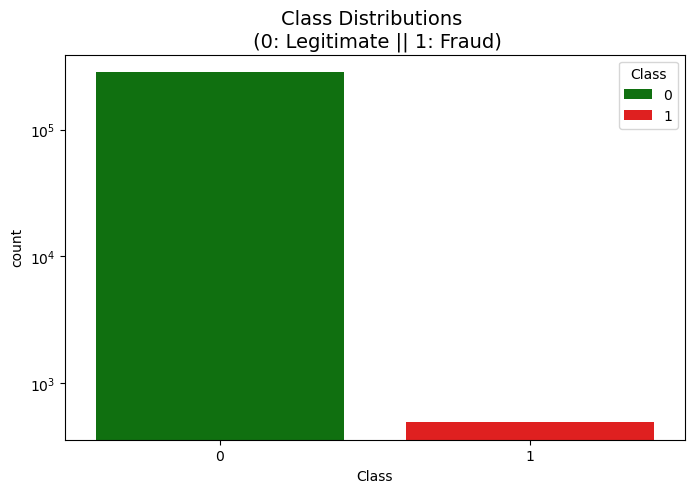

In [6]:
fig, ax = plt.subplots(1, 1, figsize = (8, 5))
# Categorical plot: count of observations in each category(x): Fraud/Not Fraud
sns.countplot(x='Class', data=df, palette=['green', 'red'], hue = 'Class', ax = ax)
ax.set_yscale('log')
ax.minorticks_off()
plt.title('Class Distributions \n (0: Legitimate || 1: Fraud)', fontsize=14)

# II. EDA

In [7]:
print("\nAmount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe().round(2))


Amount Statistics by Class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


## Comments
- Legitimate transactions: Median of $22.00, tightly concentrated in the $5.65–$77.05 range (IQR)
- Fraudulent transactions: Median of $9.25, with a much wider interquartile range ($1.00–$105.89)
- Mean values: Fraud average ($122.21) is 38% higher than legitimate average ($88.29), driven by large outliers

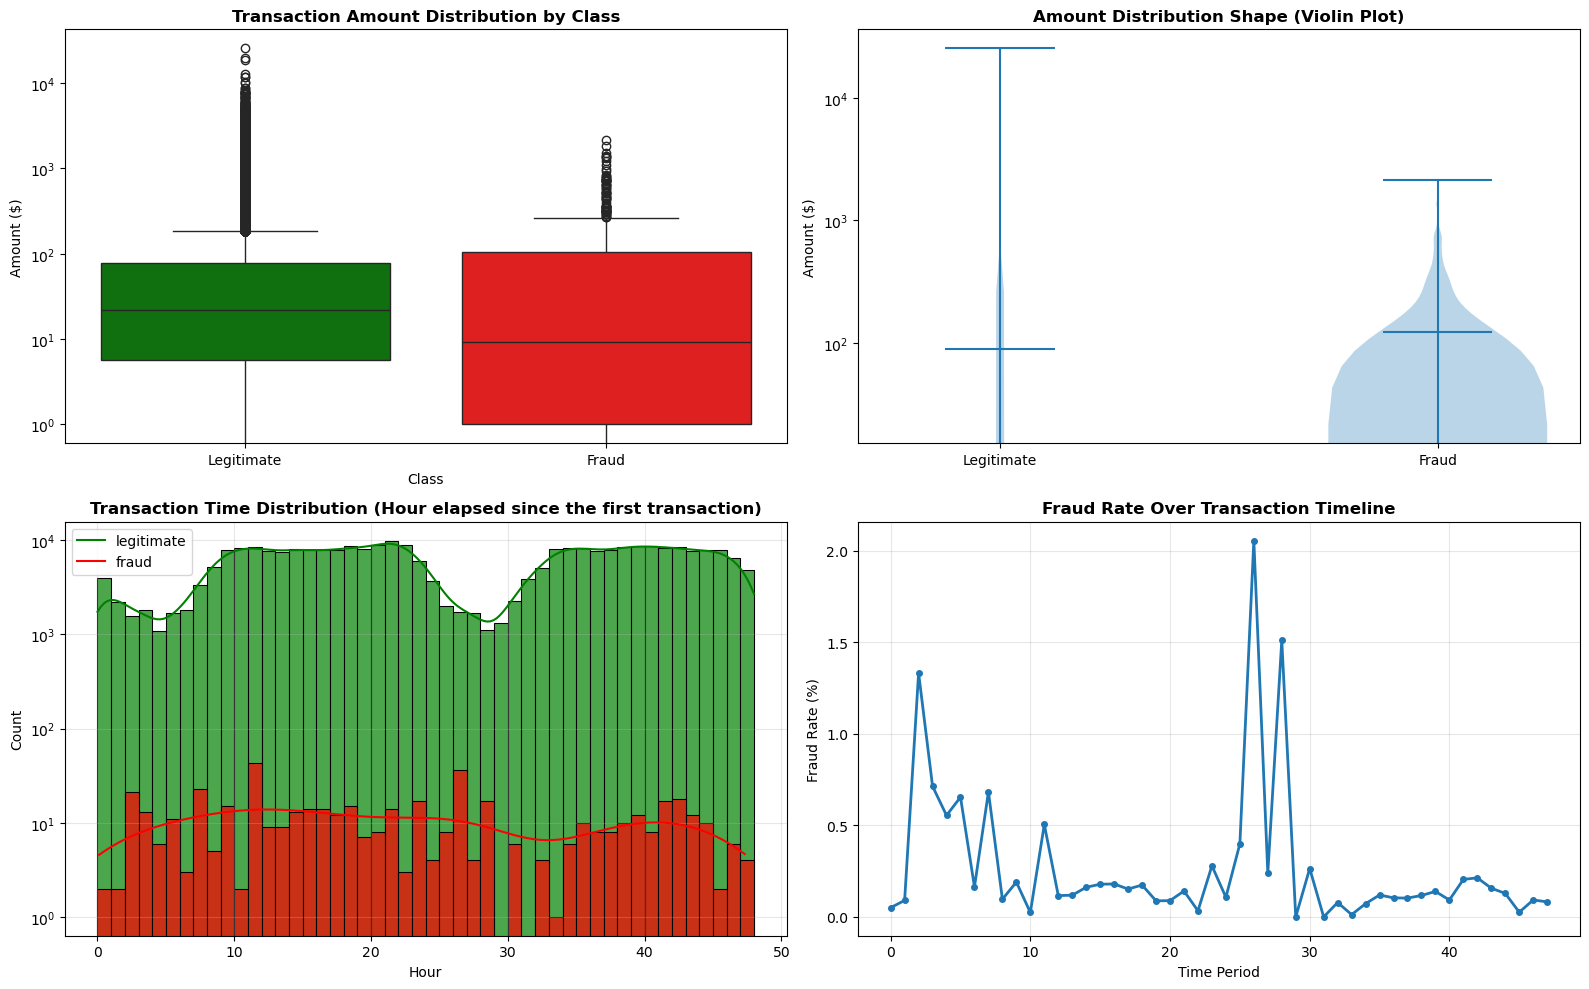

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
 
# Amount by Class - Boxplot
ax = axes[0, 0]
sns.boxplot(data = df, y='Amount', x='Class', ax=ax, palette = ['green', 'red'])
ax.set_title('Transaction Amount Distribution by Class', fontweight='bold')
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_ylabel('Amount ($)')
ax.set_xlabel('Class')
ax.set_yscale('log')
ax.minorticks_off()
 
# Amount by Class - Violin plot (better for skewed distributions)
ax = axes[0, 1]
df_fraud = df[df['Class'] == 1]['Amount']
df_legit = df[df['Class'] == 0]['Amount']
parts = ax.violinplot([df_legit, df_fraud], positions=[0, 1], showmeans=True)
ax.set_title('Amount Distribution Shape (Violin Plot)', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legitimate', 'Fraud'])
ax.set_ylabel('Amount ($)')
ax.set_yscale('log')
ax.minorticks_off()
 
# Time distribution (convert to hours)
bins = np.linspace(0, 48, 49)
ax = axes[1, 0]
df['Time_hours'] = (df['Time'] / 3600) % 48
df_time_legit = df[df['Class'] == 0]['Time_hours']
df_time_fraud = df[df['Class'] == 1]['Time_hours']
sns.histplot(df_time_legit, ax=ax, color='green', kde=True, bins = bins, alpha=0.7)
sns.histplot(df_time_fraud, ax=ax, color='red', kde=True, bins = bins, alpha=0.7)
ax.set_title('Transaction Time Distribution (Hour elapsed since the first transaction)', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.legend(['legitimate', 'fraud'])
ax.grid(alpha=0.3)
ax.minorticks_off()
 
# Fraud rate over time
ax = axes[1, 1]
time_bins = pd.cut(df['Time'], bins=48)
fraud_rate_by_time = df.groupby(time_bins)['Class'].agg(['sum', 'count'])
fraud_rate_by_time['fraud_rate'] = (fraud_rate_by_time['sum'] / fraud_rate_by_time['count'] * 100)
ax.plot(range(len(fraud_rate_by_time)), fraud_rate_by_time['fraud_rate'], marker='o', linewidth=2, markersize=4)
ax.set_title('Fraud Rate Over Transaction Timeline', fontweight='bold')
ax.set_xlabel('Time Period')
ax.set_ylabel('Fraud Rate (%)')
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

## Comments 
1. Transaction Amount Distribution by Class
    - The violin plot shows that legitimate transactions cluster heavily around low amounts with a long tail, while fraud amounts are more dispersed with two distinct peaks (small opportunistic fraud and large fraudulent attempts).
    - But the boxplot showed that using transaction amount alone would be insufficient for fraud detection because:
        + Overlap in the $5–$100 range makes it hard to separate classes by amount alone
        + A rule like "flag all transactions > $100" would miss 75% of fraud AND generate many false positives
2. Transaction Time Distribution & Fraud Rate Over Timeline
    - According to the description of dataset, we don't know if the first transaction was recorded at 0h (begining of the day) or not, so we can't analyze the behaviour of fraudulent transactions base on date time.
    - However, we can see that the fraudulent transactions spreaded throughout 48 hours.
    - The fraud rate spikes between 0.1% and 2.1% over the period.

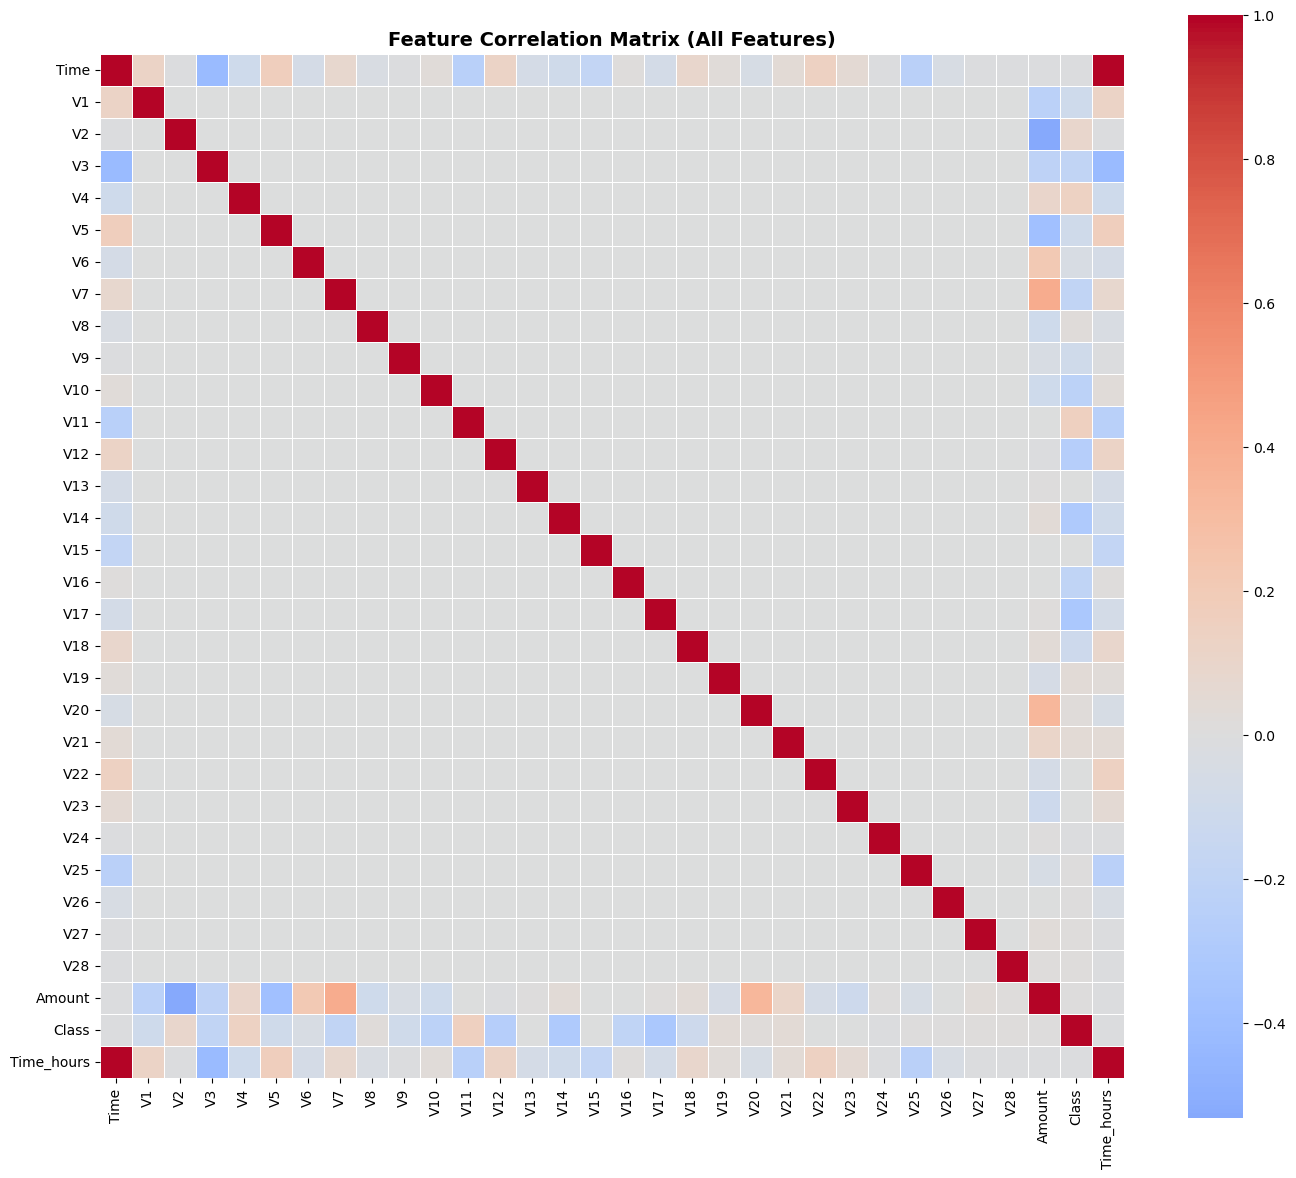


Top Features Correlated with Fraud:
1. V11: 0.1549
2. V4: 0.1334
3. V2: 0.0913
4. V21: 0.0404
5. V19: 0.0348


In [9]:
correlation_matrix = df.corr()
 
# Plot heatmap for all features
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix (All Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Most correlated with fraud (target)
print("\nTop Features Correlated with Fraud:")
fraud_corr = correlation_matrix['Class'].sort_values(ascending=False)
for i, (feature, corr_val) in enumerate(fraud_corr.items()):
    if feature != 'Class':
        print(f"{i}. {feature}: {corr_val:.4f}")
        if i >= 5:
            break

In [10]:
if 'Time_hours' in df.columns:
    df = df.drop('Time_hours', axis=1)

## Comments
- The correlation analysis reveals that PCA-transformed features are weak predictors individually:
    + Strongest correlation (V11): 0.1549 — still considered a weak correlation in statistics
    + Next 4 features: 0.0913–0.1334 — weaker
    + Pattern: All correlations are positive but modest, indicating:
        * No single feature is a strong indicator of fraud
        * Fraud detection requires combinations of features
        * The model must learn interactions between features, not rely on individual signals

# III. Preprocessing (IQR Method)
- Definition:
    + Q1: 25th percentile
    + Q2: Median (50th percentile)
    + Q3: 75th percentile
- IQR = Q3 - Q1 measures the spread of the middle 50% of the data
- Outlier boundaries (any value outside this bound is considered an outlier)
    + Lower bound: Q1 - 1.5*IQR
    + Upper bound: Q3 + 1.5*IQR

## 1. Outliers

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


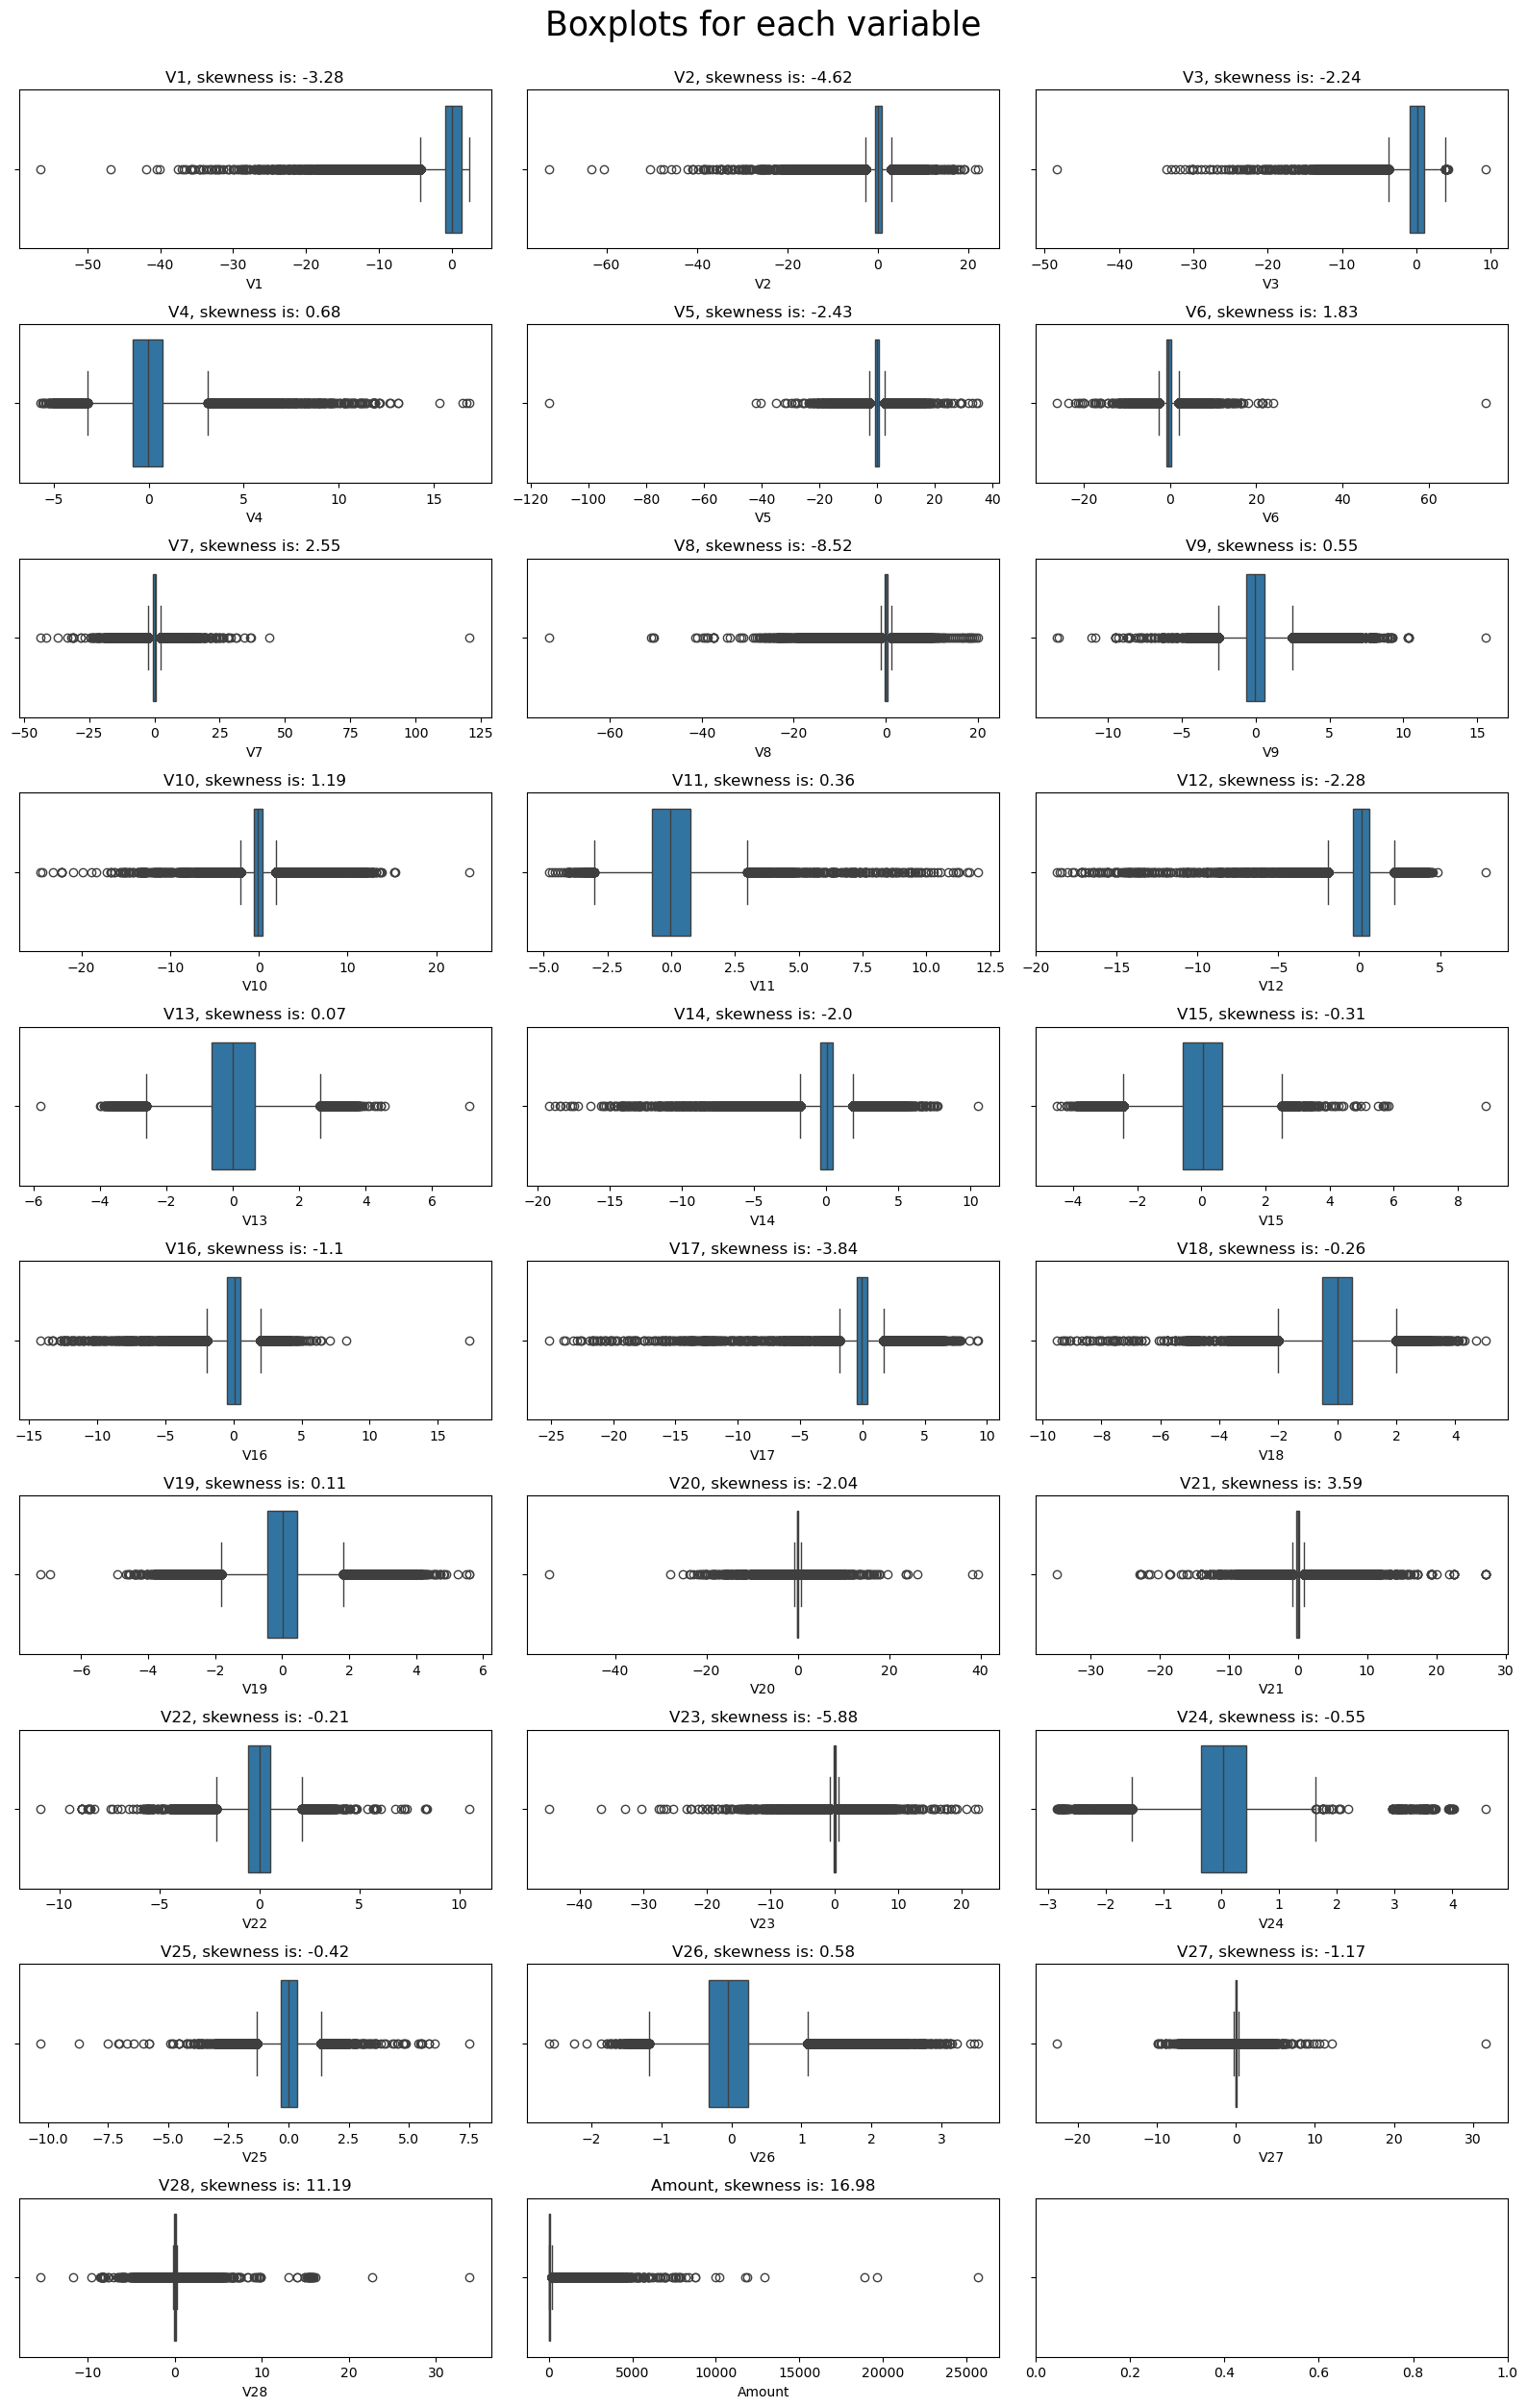

In [11]:
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,25))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, col in enumerate(columns_list):
        sns.boxplot(data=dataset[col], orient='h', ax=axs[i])
        axs[i].set_title(f"{col}, skewness is: {round(dataset[col].skew(axis = 0, skipna = True),2)}")

columns_list = df.columns.to_list()[1:-1]
print(columns_list)
boxplots_custom(dataset=df, columns_list=columns_list, rows=10, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

## 2. Remove outliers

In [12]:
def IQR_method (df,n,features):
    outlier_list = []
    
    for column in features:
        # 1st quartile (25%)
        q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        q3 = np.percentile(df[column],75)
        # Interquartile range (IQR)
        iqr = q3 - q1
        # outlier step
        outlier_step = 1.5 * iqr
        # Determining a list of indices of outliers
        outlier_list_rows = df[(df[column] < q1 - outlier_step) | (df[column] > q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_rows)
        
    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)        
    multiple_outliers = [row_id for row_id, freq in outlier_list.items() if freq > n]
    
    out = df.iloc[multiple_outliers].copy()
    out1 = out[out["Class"]  == 1].shape[0]
    out0 = out[out["Class"]  == 0].shape[0]
    print('Total number of deleted outliers belongs to class 1 is:', out1)
    print('Total number of deleted outliers belongs to class 0 is:', out0)
    return multiple_outliers

In [13]:
# detecting outliers

Outliers_IQR = IQR_method(df, 5,columns_list)

# dropping outliers
df_out = df.drop(Outliers_IQR, axis = 0).reset_index(drop=True)
df_out

Total number of deleted outliers belongs to class 1 is: 413
Total number of deleted outliers belongs to class 0 is: 13959


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270430,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
270431,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
270432,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
270433,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Comments
- Because the number of outliers in both classes is large, we decided not to remove them to avoid losing information.

# IV. Sampling methods
- We used GridSearchCV with 3-fold cross-validation to train the models. If sampling methods are applied to the dataset before training, data leakage may occur.
    + Explanation: Suppose the dataset is resampled before being split by GridSearchCV. In that case, the validation set may contain synthetic or duplicated samples generated from observations in the training folds, leading to data leakage and overly optimistic evaluation results.

- So this section only explain and visualize how sampling methods work. For better result, we should add sampler into pipeline.

In [14]:
blue_patch = mpatches.Patch(color='blue', label='Legitimate')
red_patch = mpatches.Patch(color='red', label='Fraud')

In [15]:
columns = df.columns.tolist()
columns.remove('Time')
columns.remove('Class')

In [16]:
X = df[columns].copy()
y = df["Class"].copy()

In [17]:
def create_resampled_folds(X, y, sampler):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    train_sets = []
    test_sets = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_res, y_res = sampler.fit_resample(X_train, y_train)

        train_sets.append((X_res, y_res))
        test_sets.append((X_test, y_test))

    return train_sets, test_sets

## 1. Random under-sampling (Not recommended)
- Random Under-Sampling is a technique used to handle imbalanced datasets by randomly removing samples from the majority class.
- Advantages
    + Simple and fast
    + Reduces training time
    + Helps models focus on minority class
- Disadvantages
    + Deletes potentially useful data
    + Can lose important majority-class patterns
    + May reduce model generalization
    + Especially problematic when majority class contains diverse information.

In [18]:
rus_train, rus_test = create_resampled_folds(X, y, RandomUnderSampler(sampling_strategy=0.5))

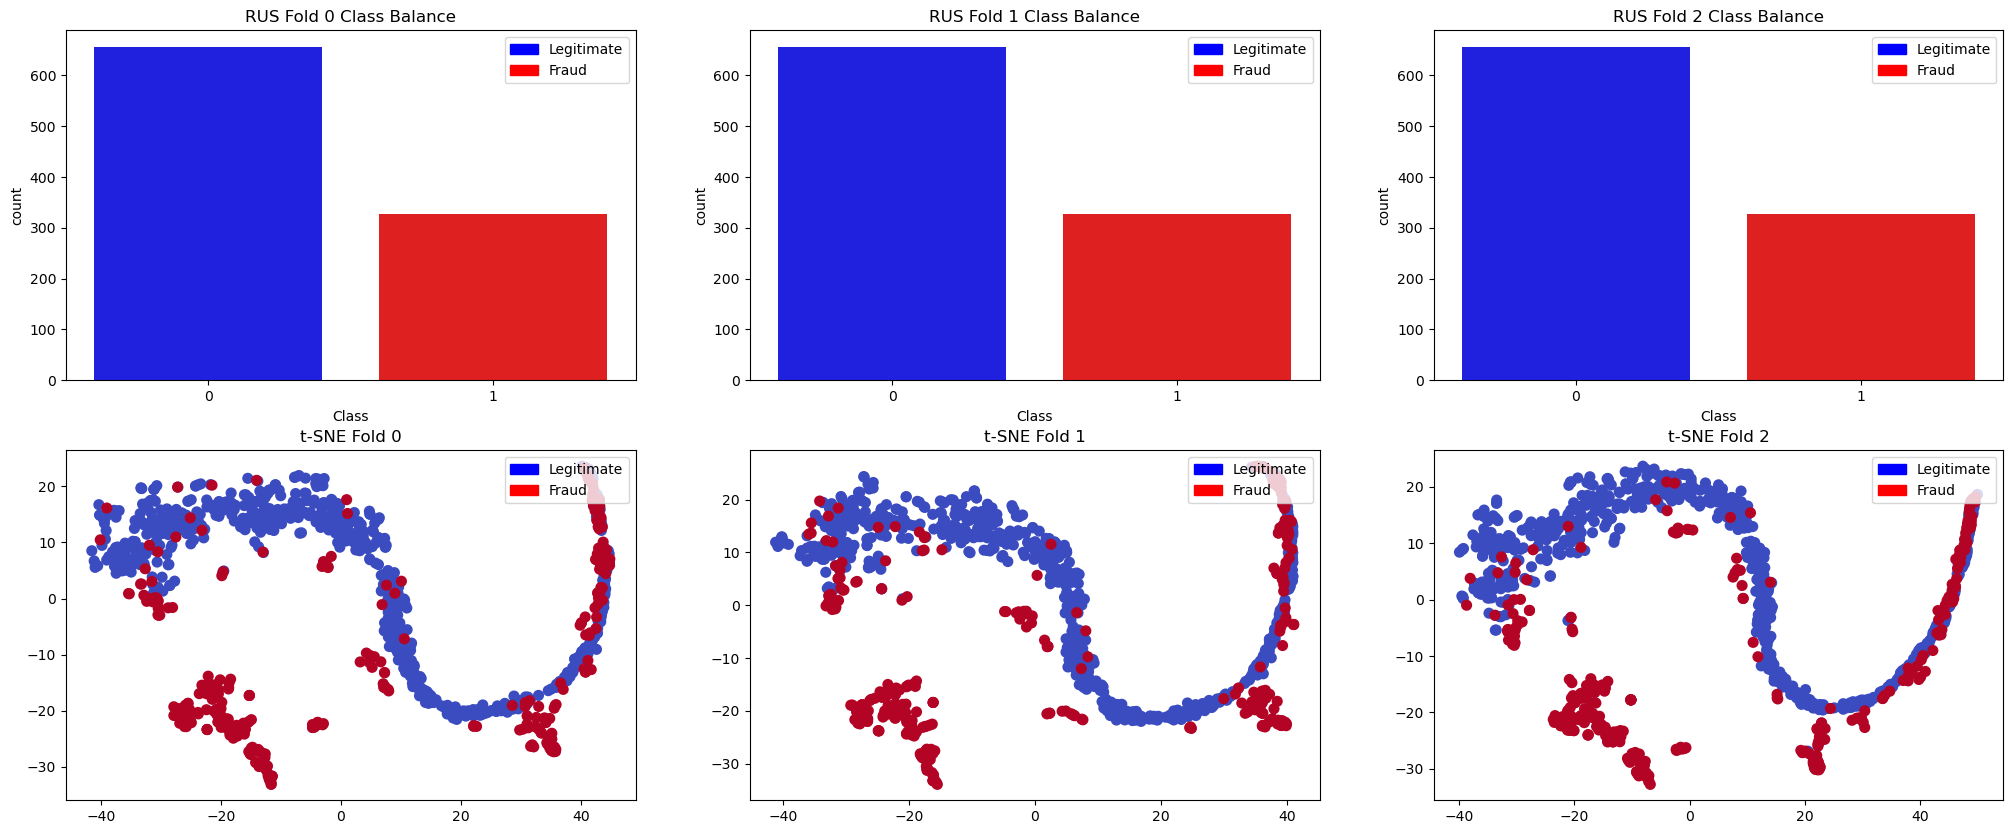

In [19]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(rus_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"RUS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles= [blue_patch, red_patch], loc = 'upper right')

## 2. NearMiss under-sampling (Not recommended)
- NearMiss is an under-sampling technique that removes majority-class samples intelligently instead of randomly.
- How NearMiss works:
    + Compute distances between majority and minority samples (Euclidean distance)
    + Keep majority samples closest to minority samples.
- Advantages: 
    + Keeps more informative samples
    + Preserves decision boundary
    + Reduces dataset size	
    + Can improve recall
- Disadvantages:
    + Still an undersampling method so it may remove useful majority information	
    + Distance calculations required (expensive with large dataset)
    + Noisy minority samples distort boundaries
    + Can overfit minority boundary


In [20]:
nearmiss_train, nearmiss_test = create_resampled_folds(X, y, NearMiss(sampling_strategy=0.5))

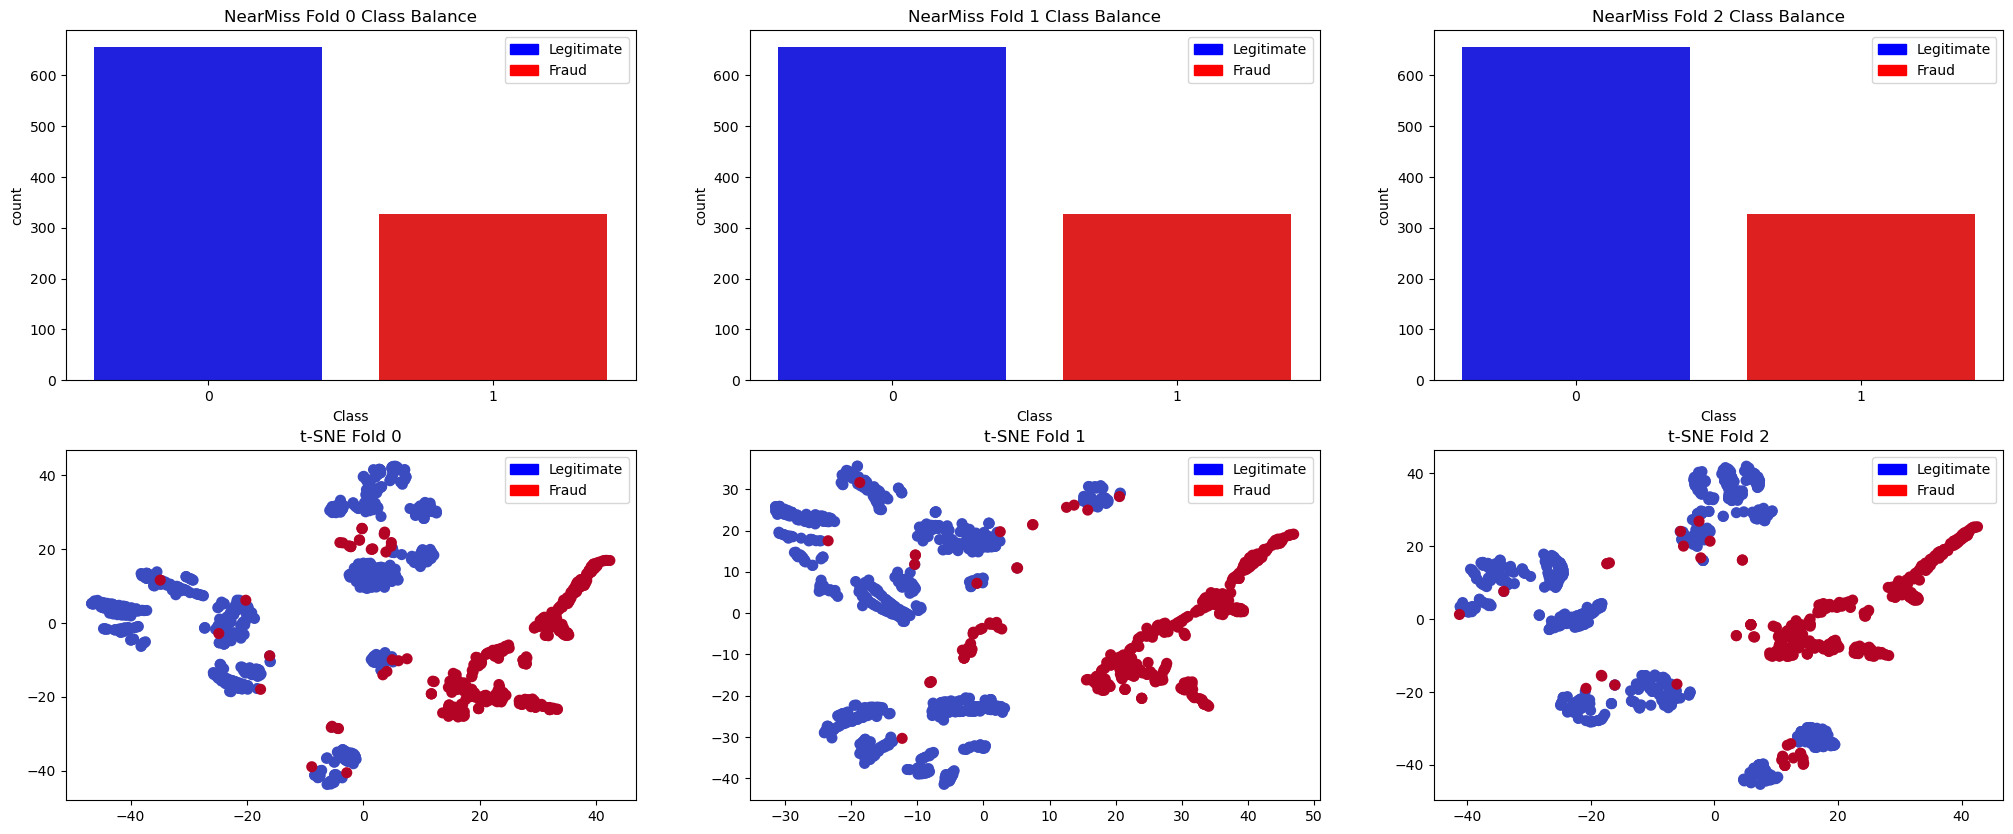

In [21]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(nearmiss_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"NearMiss Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    X_reduced = TSNE(n_components=2, random_state=42, n_jobs=1).fit_transform(X_res)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_res, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"t-SNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 3. Random over-sampling
- Random Over-Sampling balances the dataset by randomly duplicating minority-class samples.
- Advantages
    + Keeps all original data
    + Helps models learn minority patterns better
    + Often improves recall
- Disadvantages
    + Duplicates existing samples (does not create new information)
    + Can increase overfitting
    + Training becomes slower

In [22]:
ros_train, ros_test = create_resampled_folds(X, y, RandomOverSampler(sampling_strategy=0.2))

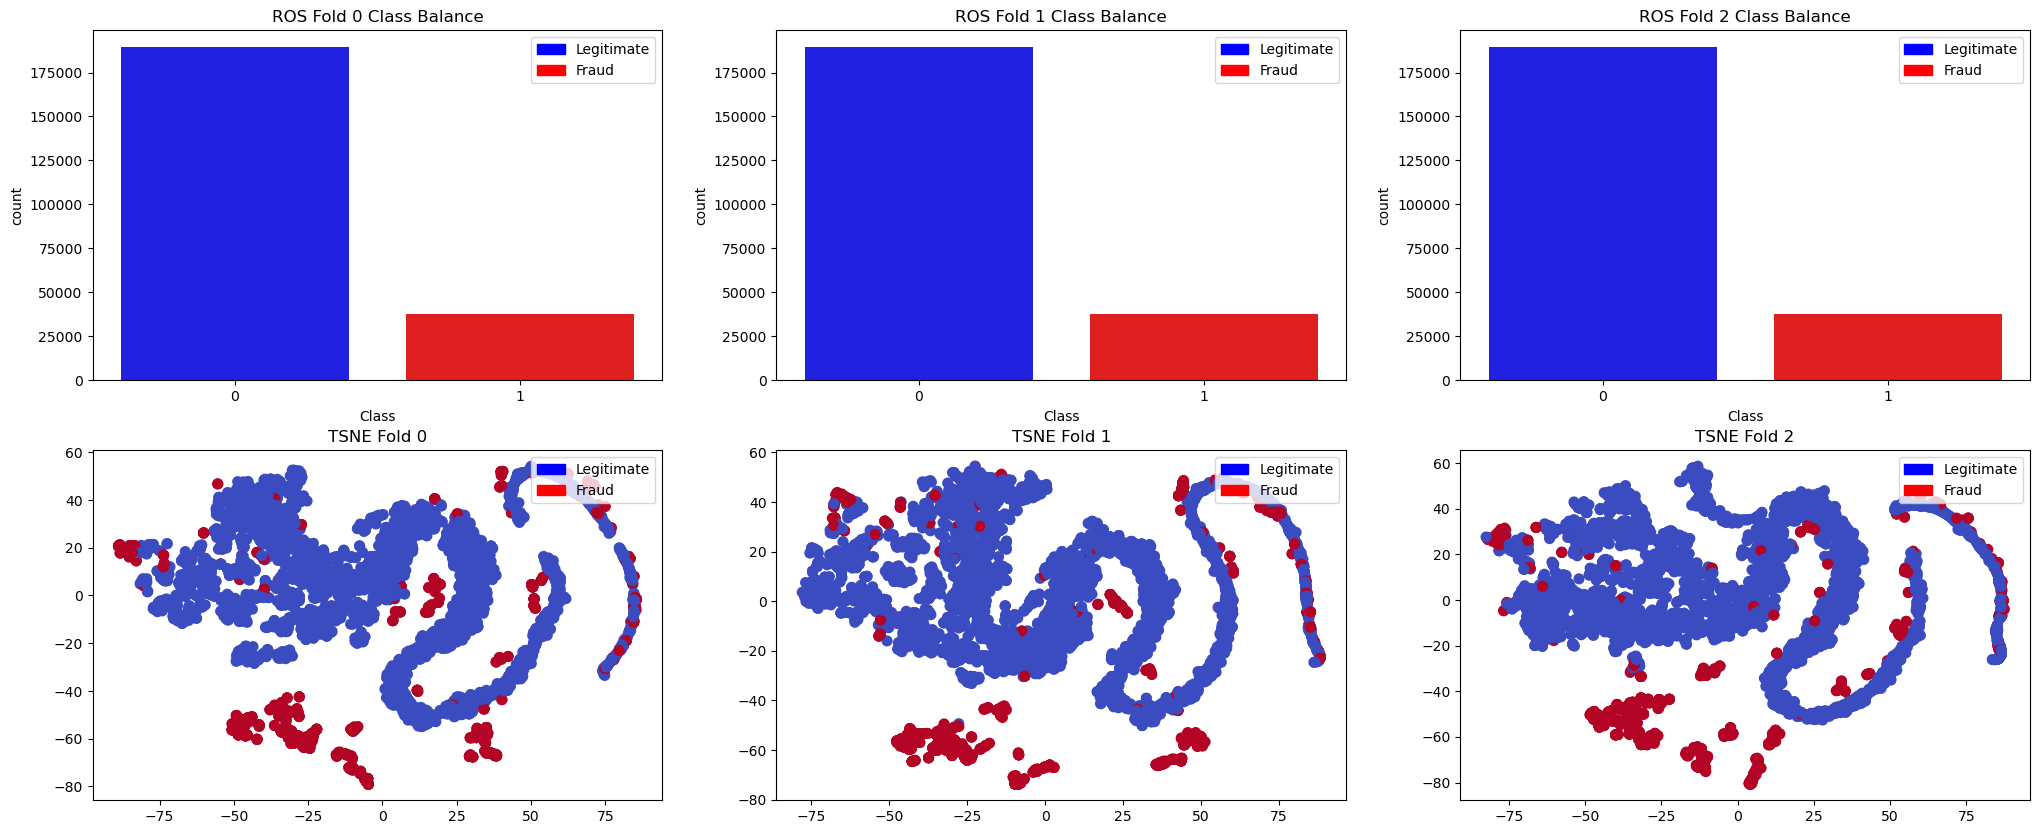

In [23]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(ros_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"ROS Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 4. SMOTE (Synthetic Minority Over-Sampling Technique)
- SMOTE is an over-sampling technique that creates synthetic minority-class samples instead of duplicating existing ones.
- How SMOTE Works:
    + For a minority sample, find nearest minority neighbors
    + Randomly choose one neighbor
    + Create a synthetic point between them
- Advantages:
    + Reduces overfitting
    + Generates new information
    + Improves minority learning
    + Often improves recall/F1
- Disadvantages:
    + Can create unrealistic samples
    + Noisy minority samples create noisy synthetic points
    + Creates overlap between classes (blur class boudaries)
    + Increases training time

In [24]:
smote_train, smote_test = create_resampled_folds(X, y, SMOTE(sampling_strategy=0.2))

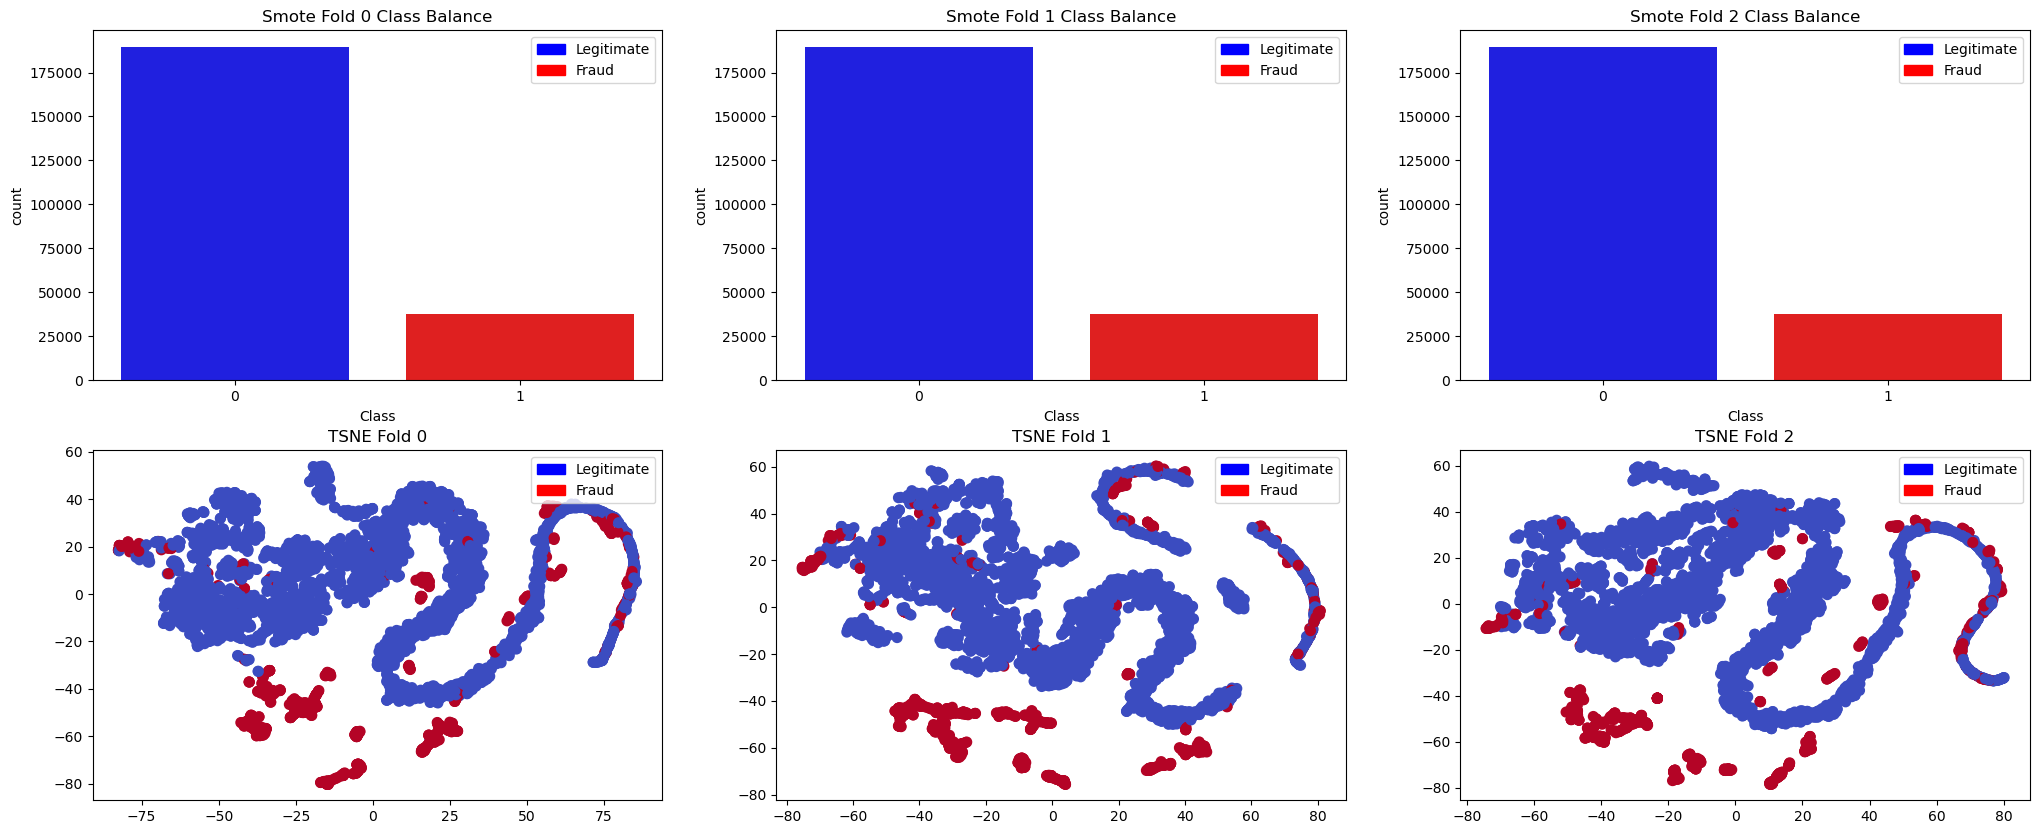

In [25]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smote_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"Smote Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

## 5. Combine Tomek and SMOTE
- SMOTETomek combines: SMOTE (oversampling) and Tomek Links (cleaning undersampling)
- How Tomek works? For 2 samples from different class, if they are each other's nearest neighbor, Tomek will remove those ambiguous samples.
- Improvement from SMOTE:
    + Tomek cleans noisy boundaries (better class separation)
- Trade off: 
    + Expensive computation cost (two-stage process)
    + May remove useful samples which are on boundaries

In [26]:
smotetomek_train, smotetomek_test = create_resampled_folds(X, y, SMOTETomek(sampling_strategy=0.2))

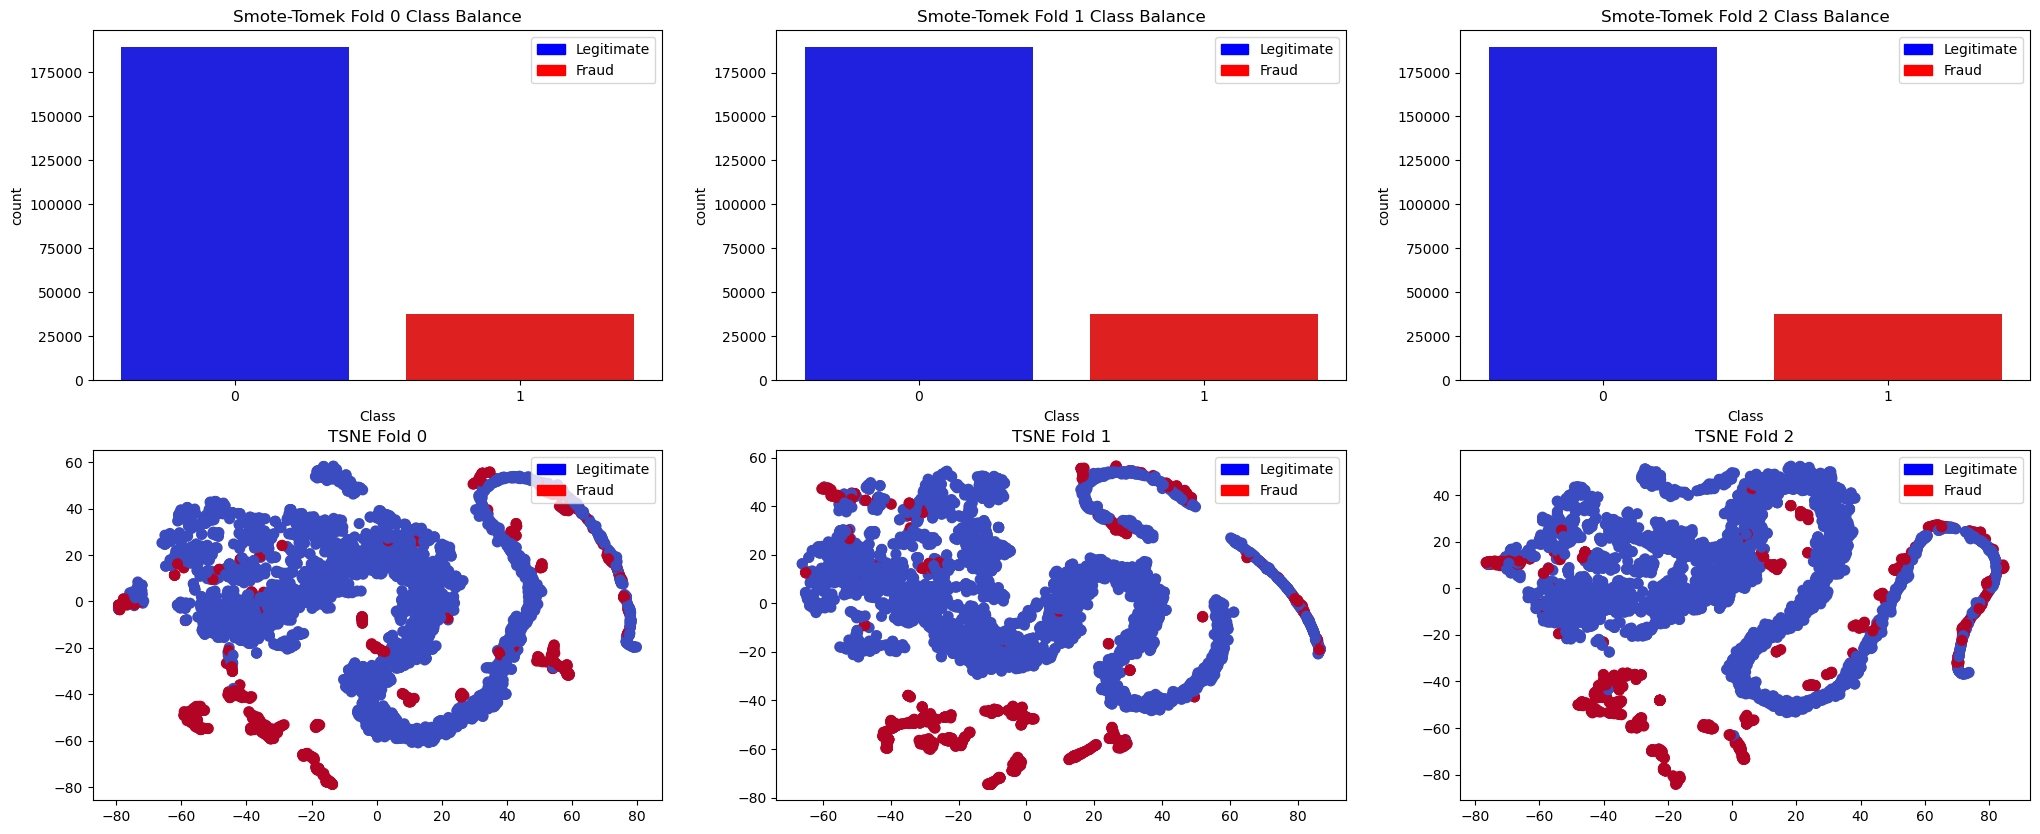

In [27]:
f, ax = plt.subplots(2, 3, figsize=(25,10))
for i, (X_res, y_res) in enumerate(smotetomek_train):
    sns.countplot(x = y_res, ax = ax[0][i], palette=['blue', 'red'], hue = y_res)
    ax[0][i].set_title(f"Smote-Tomek Fold {i} Class Balance")
    ax[0][i].legend(handles=[blue_patch, red_patch])
    idx = np.random.choice(len(X_res), size=5000, replace=False)
    X_small = X_res.iloc[idx]
    y_small = y_res.iloc[idx]
    X_reduced = TSNE(n_components=2).fit_transform(X_small)
    ax[1][i].scatter(X_reduced[:,0], X_reduced[:,1], c=y_small, cmap='coolwarm', linewidths=2)
    ax[1][i].set_title(f"TSNE Fold {i}")
    ax[1][i].legend(handles=[blue_patch, red_patch], loc = 'upper right')

# V. Training models
## Model Selection

We selected several machine learning models with different learning characteristics to compare their effectiveness on the fraud detection task.

- **Logistic Regression** was chosen as a simple and interpretable baseline model. It performs well on linearly separable data and provides probability outputs that are useful for threshold tuning.

- **Random Forest** was chosen because it is an ensemble tree-based model capable of capturing nonlinear relationships and feature interactions. It is also robust to noise and less sensitive to outliers.

- **XGBoost** was selected due to its strong performance on tabular and imbalanced datasets. Its boosting mechanism allows the model to sequentially correct previous errors, often leading to superior predictive performance in fraud detection tasks.
---
## Evaluation Metric

We used **Average Precision (AP)** as the main evaluation metric because the dataset is highly imbalanced. Accuracy is not reliable in this scenario since a model can achieve high accuracy by predicting most transactions as legitimate.

Average Precision summarizes the Precision-Recall curve and evaluates the model’s ability to correctly rank fraudulent transactions higher than legitimate ones across different thresholds. This metric is more informative for fraud detection because it emphasizes performance on the minority (fraud) class.

---
## Spliting training and testing dataset

We used train_test_split with stratify=y to preserve the class distribution when splitting the dataset into training and testing sets.

---
## Cross Validation

We used StratifiedKFold(n_splits=3, shuffle=True, random_state=42) to split the training set into 3 folds, with each fold preserving the class distribution.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

## 1. Building pipeline

In [45]:
def run_model(model_sampler, model, sampler, param_grid, X_train, X_test, y_train, y_test):
    steps = []
    steps.append(('scaler', RobustScaler()))
    if sampler is not None:
        steps.append(('sampler', sampler))

    steps.append(('clf', model))

    pipe = Pipeline(steps)
    
    start = time.time()
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='average_precision',
        n_jobs=-1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    )
    grid.fit(X_train, y_train)
    
    end = time.time()
    print("Best Params:", grid.best_params_)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    trained_time = end - start
    recall_s = recall_score(y_test, y_pred)
    pre_s = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"Trained time: {trained_time:.2f}s")
    print("Recall:", recall_s)
    print("Precision:", pre_s)
    print("F1-score: ", f1)
    print("\n")

    return {"model_name":model_sampler,
            "model": best_model,
            "model_score": grid.best_score_, 
            "best_params":grid.best_params_, 
            "recall_score":recall_s,
            "precision_score":pre_s,
            "f1-score":f1,
            "time": round(trained_time,2)}


## 2. Training model
### a. Logistic Regression

In [46]:
results = []

In [47]:
params_grid_log = {'clf__C': [0.01, 0.1, 1, 10, 100]}

In [48]:
logreg = run_model("LogisticRegression + balanced class_weight", LogisticRegression(class_weight='balanced', max_iter=3000), 
                   None, 
                   params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg)

Best Params: {'clf__C': 0.1}
Trained time: 8.81s
Recall: 0.9183673469387755
Precision: 0.05921052631578947
F1-score:  0.11124845488257108




In [49]:
logreg_ros = run_model("LogisticRegression + Random Over Sampling",LogisticRegression(max_iter=3000), 
                       RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_ros)

Best Params: {'clf__C': 1}
Trained time: 6.04s
Recall: 0.8877551020408163
Precision: 0.23076923076923078
F1-score:  0.3663157894736842




In [50]:
logreg_rus = run_model("LogisticRegression + Random Under Sampling",LogisticRegression(max_iter=3000), 
                       RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                       params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_rus)

Best Params: {'clf__C': 100}
Trained time: 1.08s
Recall: 0.9183673469387755
Precision: 0.05253940455341506
F1-score:  0.09939260077305356




In [51]:
logreg_nm = run_model("LogisticRegression + Nearmiss",LogisticRegression(max_iter=3000), 
                      NearMiss(sampling_strategy=0.5), 
                      params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_nm)

Best Params: {'clf__C': 0.01}
Trained time: 2.15s
Recall: 0.8775510204081632
Precision: 0.03577371048252912
F1-score:  0.06874500399680256




In [52]:
logreg_smotetomek = run_model("LogisticRegression + SmoteTomek",LogisticRegression(max_iter=3000), 
                              SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')), 
                              params_grid_log, X_train, X_test, y_train, y_test)
results.append(logreg_smotetomek)

Best Params: {'clf__C': 100}
Trained time: 272.15s
Recall: 0.8877551020408163
Precision: 0.2175
F1-score:  0.3493975903614458




### b. Random Forest

In [53]:
params_grid_rf = {
    'clf__n_estimators': [150, 300],
    'clf__max_depth':  [5, 10],
    "clf__min_samples_leaf": [50, 100, 300],
}

In [54]:
rf = run_model("RandomForest + balanced class_weight",RandomForestClassifier(class_weight='balanced', random_state=42), 
               None, 
               params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 300}
Trained time: 767.25s
Recall: 0.8877551020408163
Precision: 0.6444444444444445
F1-score:  0.7467811158798283




In [55]:
rf_ros = run_model("RandomForest + Random Over Sampling",RandomForestClassifier(random_state=42), 
                   RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_ros)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 835.04s
Recall: 0.8877551020408163
Precision: 0.6641221374045801
F1-score:  0.759825327510917




In [56]:
rf_rus = run_model("RandomForest + Random Under Sampling", RandomForestClassifier(random_state=42), 
                   RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                   params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_rus)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 7.74s
Recall: 0.8775510204081632
Precision: 0.36752136752136755
F1-score:  0.5180722891566265




In [57]:
rf_nm = run_model("RandomForest + Nearmiss",RandomForestClassifier(random_state=42), 
                  NearMiss(sampling_strategy=0.5), 
                  params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_nm)

Best Params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 300}
Trained time: 6.82s
Recall: 0.9183673469387755
Precision: 0.0042765502494654314
F1-score:  0.008513455990162228




In [58]:
rf_smotetomek = run_model("RandomForest + SmoteTomek",RandomForestClassifier(random_state=42), 
                     SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')),
                     params_grid_rf, X_train, X_test, y_train, y_test)
results.append(rf_smotetomek)

Best Params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 150}
Trained time: 1551.62s
Recall: 0.8877551020408163
Precision: 0.6258992805755396
F1-score:  0.7341772151898734




### c. XGBoost

In [59]:
params_grid_xgb = {
    'clf__scale_pos_weight': [500, 580],  
    'clf__min_child_weight': [5, 7, 9],        
    'clf__gamma': [0.3, 0.5],         
    'clf__max_depth': [5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1],  
    'clf__n_estimators': [300],
    'clf__eval_metric': ['logloss']
}

In [60]:
xgb = run_model("XGBoost", XGBClassifier(random_state = 42),
                None, 
                params_grid_xgb, X_train, X_test, y_train, y_test)
results.append(xgb)

Best Params: {'clf__eval_metric': 'logloss', 'clf__gamma': 0.3, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 5, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 500}
Trained time: 165.35s
Recall: 0.8571428571428571
Precision: 0.8571428571428571
F1-score:  0.8571428571428571




In [61]:
params_grid_xgb_sampling = {
    'clf__scale_pos_weight': [2, 3],  
    'clf__min_child_weight': [7, 9, 11],        
    'clf__gamma': [0.5, 0.7],         
    'clf__max_depth': [5, 7],
    'clf__learning_rate': [0.1, 0.2],  
    'clf__n_estimators': [300, 500],
    'clf__eval_metric': ['logloss']
}



In [62]:
xgb_ros = run_model("XGBoost + Random Over Sampling", XGBClassifier(random_state = 42),
                    RandomOverSampler(sampling_strategy=0.2, random_state=42), 
                    params_grid_xgb_sampling, X_train, X_test, y_train, y_test)
results.append(xgb_ros)

Best Params: {'clf__eval_metric': 'logloss', 'clf__gamma': 0.7, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 9, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 2}
Trained time: 196.41s
Recall: 0.8775510204081632
Precision: 0.86
F1-score:  0.8686868686868687




In [63]:
xgb_rus = run_model("XGBoost + Random Under Sampling", XGBClassifier(random_state = 42),
                    RandomUnderSampler(sampling_strategy=0.5, random_state=42), 
                    params_grid_xgb_sampling, X_train, X_test, y_train, y_test)
results.append(xgb_rus)

Best Params: {'clf__eval_metric': 'logloss', 'clf__gamma': 0.5, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__min_child_weight': 7, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 3}
Trained time: 16.49s
Recall: 0.9183673469387755
Precision: 0.04269449715370019
F1-score:  0.0815956482320943




In [64]:
xgb_nm = run_model("XGBoost + Nearmiss", XGBClassifier(random_state = 42),
                    NearMiss(sampling_strategy=0.5), 
                    params_grid_xgb_sampling, X_train, X_test, y_train, y_test)
results.append(xgb_nm)

Best Params: {'clf__eval_metric': 'logloss', 'clf__gamma': 0.7, 'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__min_child_weight': 11, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 2}
Trained time: 26.07s
Recall: 0.9795918367346939
Precision: 0.0020967107849561
F1-score:  0.0041844651730450705




In [65]:
xgb_smotetomek = run_model("XGBoost + SmoteTomek", XGBClassifier(random_state = 42),
                            SMOTETomek(smote=SMOTE(sampling_strategy=0.2, random_state=42), tomek=TomekLinks(sampling_strategy='majority')),
                            params_grid_xgb_sampling, X_train, X_test, y_train, y_test)
results.append(xgb_smotetomek)

Best Params: {'clf__eval_metric': 'logloss', 'clf__gamma': 0.5, 'clf__learning_rate': 0.2, 'clf__max_depth': 7, 'clf__min_child_weight': 11, 'clf__n_estimators': 300, 'clf__scale_pos_weight': 2}
Trained time: 4495.49s
Recall: 0.8469387755102041
Precision: 0.7280701754385965
F1-score:  0.7830188679245284




## 3. Model comparison
- There are 2 problems in this task:
    + The cost of missing a fraudulent transaction is severer than the cost of mistakenly capturing the legitimate one
    + But we can't either ignore the convinience/comfort of the customers
- Choosing model with high recall and acceptable precision scores will solve problems
- In this notebook, the overall score is computed based on recall and precision score with weights of 0.8 and 0.2, respectively.

In [66]:
results_df = pd.DataFrame(results)
results_df["scaled_score"] = 0.8*results_df.loc[:, 'recall_score'] + 0.2*results_df.loc[:,'precision_score']
results_df = results_df.sort_values(by=['scaled_score'], ascending=[False]).reset_index(drop=True)
display_results = results_df.drop(columns=['model', 'model_score', 'best_params'])
display_results

,model_name,recall_score,precision_score,f1-score,time,scaled_score
0,XGBoost + Random Over Sampling,0.877551,0.860000,0.868687,196.41,0.874041
1,XGBoost,0.857143,0.857143,0.857143,165.35,0.857143
2,RandomForest + Random Over Sampling,0.887755,0.664122,0.759825,835.04,0.843029
3,RandomForest + balanced class_weight,0.887755,0.644444,0.746781,767.25,0.839093
4,RandomForest + SmoteTomek,0.887755,0.625899,0.734177,1551.62,0.835384
5,XGBoost + SmoteTomek,0.846939,0.728070,0.783019,4495.49,0.823165
6,XGBoost + Nearmiss,0.979592,0.002097,0.004184,26.07,0.784093
7,RandomForest + Random Under Sampling,0.877551,0.367521,0.518072,7.74,0.775545
8,LogisticRegression + Random Over Sampling,0.887755,0.230769,0.366316,6.04,0.756358
9,LogisticRegression + SmoteTomek,0.887755,0.217500,0.349398,272.15,0.753704


# VI. Explainable AI - SHAP Analysis

## Overview
After identifying the best-performing models, we use SHAP (SHapley Additive exPlanations) to understand how individual features influence fraud predictions. SHAP provides model-agnostic explanations by quantifying the contribution of each feature to a prediction, which can be expressed as:

Prediction = Base Value + Sum of SHAP Contributions

## Key Considerations
**Dataset Limitation**: The dataset uses anonymized PCA-transformed variables (V1–V28). Therefore, SHAP explanations identify influential latent components rather than business-interpretable features. In a real-world scenario with original features (e.g., transaction location, merchant category, time of day), SHAP would reveal directly actionable insights such as "transactions from high-risk countries" or "unusually high amounts." Here, we can identify *patterns* (e.g., "latent component V15 strongly indicates fraud") but cannot directly map these back to business meanings without access to the original feature space.

## Explanations Provided
1. **SHAP Summary Plot (Bar)**: Shows the global feature importance across all predictions
2. **SHAP Dependence Plots**: Illustrates how feature values influence model output for top features
3. **SHAP Force Plots**: Individual prediction explanations showing how features push the prediction toward fraud or legitimate
4. **SHAP Decision Plots**: Visualizes the decision-making process across multiple samples
## Business Implications
1. **Most Influential Features**: The top features identified by SHAP represent latent patterns in the data that most strongly indicate fraud
2. **Individual Explanations**: For any transaction flagged by the model, SHAP can explain which features contributed to the decision
3. **Model Validation**: If the top features make business sense (even after PCA transformation), it increases confidence in the model
4. **Debugging**: Unusual SHAP patterns might indicate:
   - Data quality issues
   - Model overfitting
   - Distribution shifts in new data

In [67]:
np.random.seed(42)
sample_indices = np.random.choice(X_test.shape[0], size=min(5000, X_test.shape[0]), replace=False)
X_test_sample = X_test.iloc[sample_indices].reset_index(drop=True)
y_test_sample = y_test.iloc[sample_indices].reset_index(drop=True)

print(f"Test sample size: {X_test_sample.shape[0]}")
print(f"Fraud cases in sample: {y_test_sample.sum()} ({100*y_test_sample.sum()/len(y_test_sample):.2f}%)")
print(f"Features shape: {X_test_sample.shape}")

Test sample size: 5000
Fraud cases in sample: 5 (0.10%)
Features shape: (5000, 29)


In [68]:
def explain_model(model, X_test_sample):
    scaler = model.named_steps['scaler']
    classifier = model.named_steps['clf']
    
    feature_names = X_test_sample.columns.tolist()
    X_sample_transformed = scaler.transform(X_test_sample)

    classifier_type = type(classifier).__name__
    print(classifier_type)

    if 'RandomForestClassifier' in classifier_type:
        explainer = shap.TreeExplainer(classifier, feature_perturbation='interventional')

        shap_values = explainer.shap_values(X_sample_transformed)
        base_value = explainer.expected_value
    else:
        background = shap.sample(X_sample_transformed, min(100, len(X_sample_transformed)))
        explainer = shap.KernelExplainer(classifier.predict_proba, background)

        shap_values = explainer.shap_values(X_sample_transformed)
        base_value = explainer.expected_value
    
    if isinstance(base_value, (list, np.ndarray)):
        base_value = float(base_value[1])
    else:
        base_value = float(base_value)
    
    return explainer, shap_values, base_value, X_sample_transformed, feature_names

In [69]:
best_model = results_df.loc[0, 'model']
best_model_name = results_df.loc[0, 'model_name']
explainer, shap_values, base_value, X_sample_transformed, feature_names = explain_model(best_model, X_test_sample)
# Get the base value (expected model output)
print(base_value)


XGBClassifier


100%|██████████| 5000/5000 [15:17<00:00,  5.45it/s]

0.00014470873771017524


In [70]:
shap_values_fraud = shap_values[:, :, 1] # shap values of class 1
print(shap_values_fraud.shape)

(5000, 29)


## 1. SHAP Summary Plots (Feature Importance)

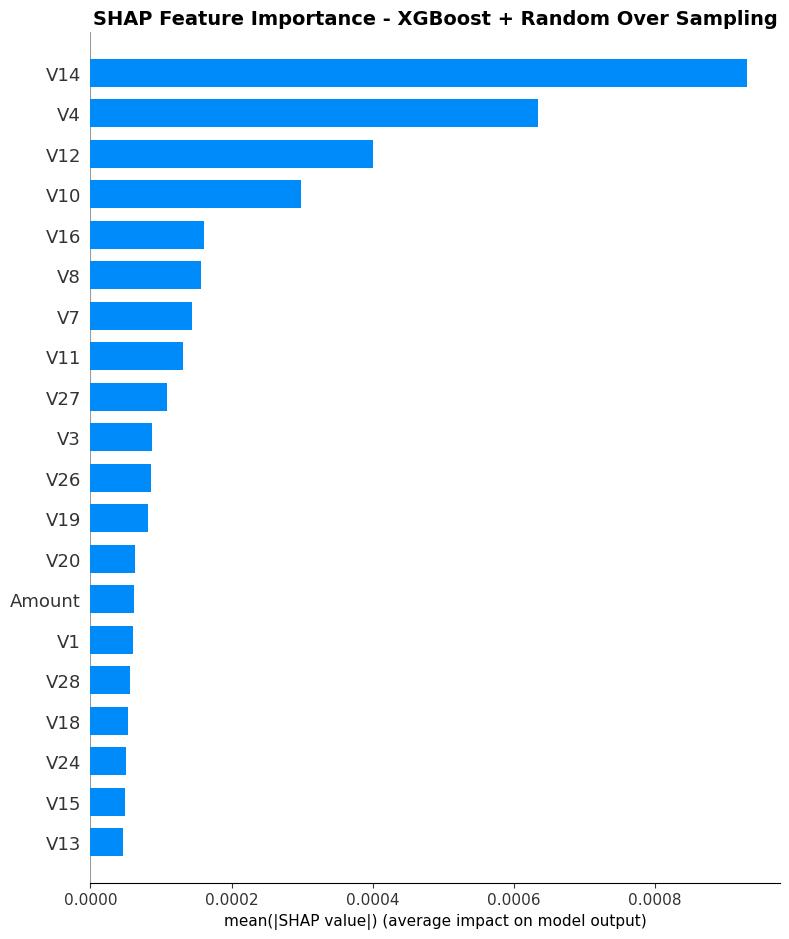


XGBoost + Random Over Sampling: Features importance for fraud prediction


In [71]:
plt.figure(figsize=(15, 10))
shap.summary_plot(shap_values_fraud, X_sample_transformed, show=False, feature_names=feature_names, plot_type='bar')
plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('mean(|SHAP value|) (average impact on model output)', fontsize=11)
plt.tight_layout()
plt.show()
print(f"\n{best_model_name}: Features importance for fraud prediction")

## 2. SHAP Dependence Plots (Feature Impact Analysis)

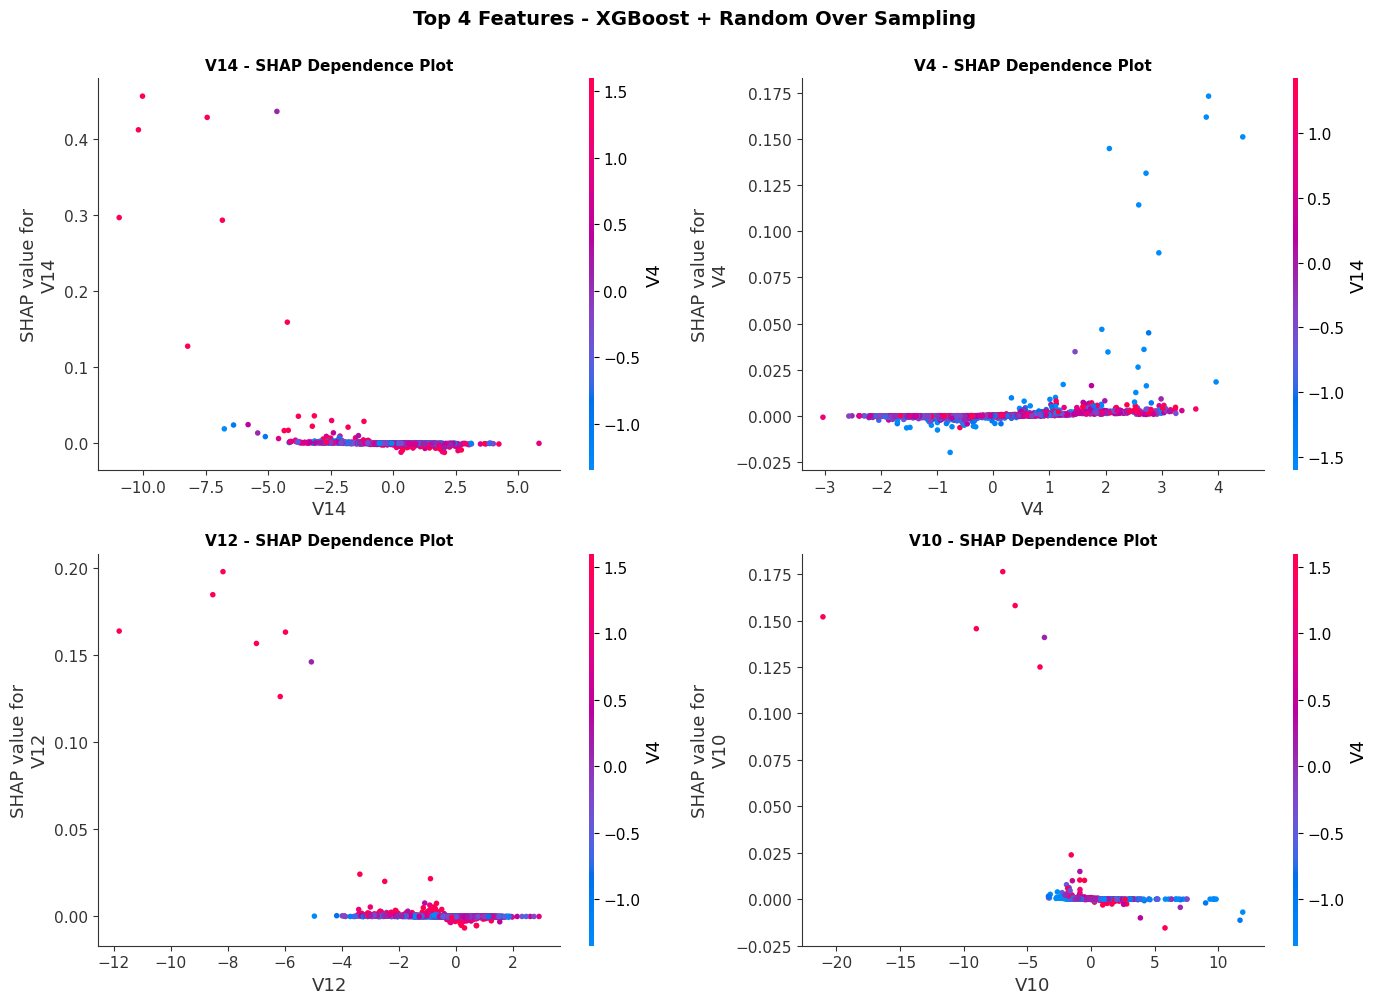

Interpretation: Each dot represents a transaction.
X-axis: Feature value | Y-axis: SHAP value (contribution to fraud prediction)
Red/Blue color: Interaction with another important feature


In [72]:
feature_importance = np.abs(shap_values_fraud).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-4:][::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature_idx in enumerate(top_features_idx):
    feature_name = feature_names[feature_idx]  
    ax = axes[idx]
    
    shap.dependence_plot(feature_idx, shap_values_fraud, X_sample_transformed, 
                        feature_names=feature_names,  
                        ax=ax, show=False)
    ax.set_title(f'{feature_name} - SHAP Dependence Plot', fontsize=11, fontweight='bold')

plt.suptitle(f'Top 4 Features - {best_model_name}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Interpretation: Each dot represents a transaction.")
print("X-axis: Feature value | Y-axis: SHAP value (contribution to fraud prediction)")
print("Red/Blue color: Interaction with another important feature")

### Comments:
- SHAP analysis shows that transactions with highly negative V14 values substantially increase the predicted probability of fraud. The effect becomes particularly strong when V14 falls below approximately -5.
- V4 exhibits a positive monotonic relationship with fraud risk. Higher V4 values consistently increase the model's fraud prediction.
- V12 exhibited a pattern similar to V14, with highly negative values contributing significantly to the model's fraud predictions.
- V10 demonstrates a threshold-like effect, where highly negative values substantially increase fraud probability, whereas positive values contribute little to the prediction.

## 3. SHAP Force Plots (Individual Prediction Explanations)

In [73]:
# Find fraud and non-fraud examples
fraud_idx = np.where(y_test_sample == 1)[0]
legitimate_idx = np.where(y_test_sample == 0)[0]

print(f"Fraud examples: {len(fraud_idx)}, Non-fraud examples: {len(legitimate_idx)}")

# Get one example from each class
fraud_example_idx = fraud_idx[0] 
legitimate_example_idx = legitimate_idx[0]



Fraud examples: 5, Non-fraud examples: 4995


Fraud transaction example
Actual Class: Fraud (1)


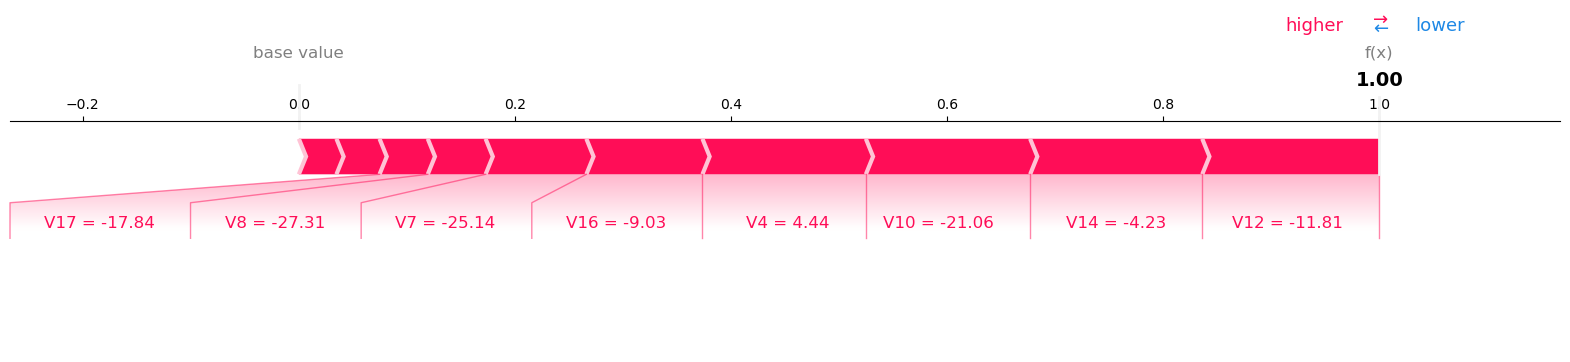

In [74]:
print(f"Fraud transaction example")
print(f"Actual Class: Fraud (1)")

rounded_features_fraud = np.round(X_sample_transformed[fraud_example_idx], 2)

shap.force_plot(base_value, shap_values_fraud[fraud_example_idx],
                rounded_features_fraud, feature_names=feature_names,
                matplotlib=True)

Legitimate transaction example
Actual Class: Legitimate (0)


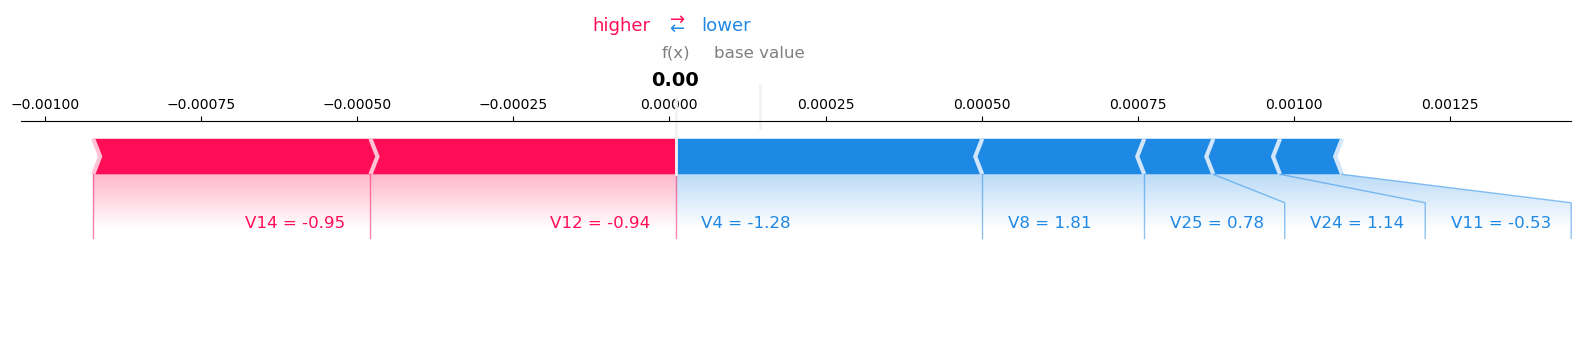

In [75]:
print(f"Legitimate transaction example")
print(f"Actual Class: Legitimate (0)")

rounded_features_legitmate = np.round(X_sample_transformed[legitimate_example_idx], 2)

force_plot_legit = shap.force_plot(base_value, shap_values_fraud[legitimate_example_idx], 
                                    rounded_features_legitmate, feature_names=feature_names,  
                                    matplotlib=True)


### Comments:
- For the selected fraudulent transaction, SHAP analysis shows that features V14, V17, V10, V12, and V4 contributed most strongly to the fraud prediction. In particular, the highly negative value of V14 exerted the largest positive influence on the model output. Starting from a baseline fraud probability of approximately 0.03%, the combined contributions of these features increased the predicted fraud probability to nearly 100%, resulting in a confident and correct fraud classification.

- The force plot reveals that the selected legitimate transaction contains both fraud-indicating and legitimacy-indicating characteristics. Specifically, the negative values of V14 and V12 contribute positively to the fraud prediction. However, features such as V4, V8, V25, V24, and V11 exert stronger negative contributions, outweighing the fraud signals. As a result, the predicted fraud probability remains close to zero, leading the model to classify the transaction as legitimate with high confidence.

## 4. SHAP Decision Plots (Model Decision Path)

Decision Plot - Fraudulent Transactions


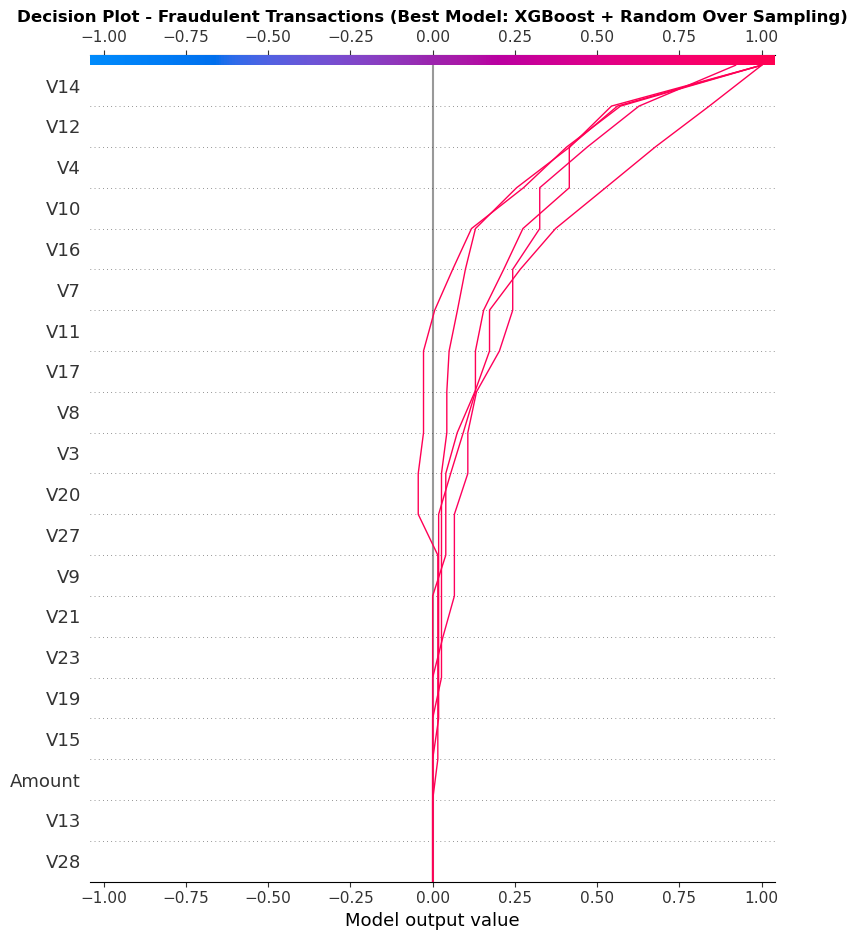

In [76]:
fraud_mask = (y_test_sample == 1)
legitimate_mask = (y_test_sample == 0)

# Plot decision plot for fraud cases (if available)
print("Decision Plot - Fraudulent Transactions")
fig = plt.figure(figsize=(14, 8))
shap.decision_plot(base_value, shap_values_fraud[fraud_mask][:min(500, fraud_mask.sum())], 
                    X_sample_transformed[fraud_mask][:min(500, fraud_mask.sum())],
                    feature_names=feature_names,  
                    show=False)
plt.title(f'Decision Plot - Fraudulent Transactions (Best Model: {best_model_name})', 
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Decision Plot - Legitimate Transactions


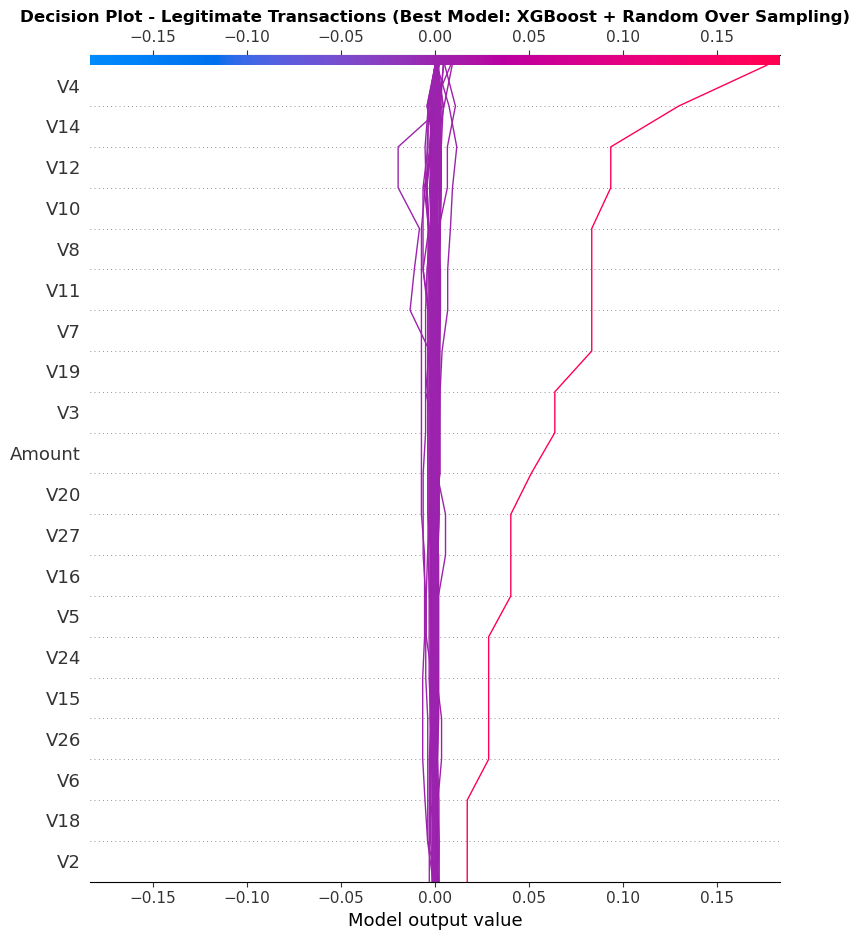

In [77]:
print("\nDecision Plot - Legitimate Transactions")
fig = plt.figure(figsize=(14, 8))
shap.decision_plot(base_value, shap_values_fraud[legitimate_mask][:min(500, legitimate_mask.sum())], 
                    X_sample_transformed[legitimate_mask][:min(500, legitimate_mask.sum())],
                    feature_names=feature_names,  
                    show=False)
plt.title(f'Decision Plot - Legitimate Transactions (Best Model: {best_model_name})', 
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Comments
- The decision plots reveal distinct patterns between fraudulent and legitimate transactions. For fraudulent transactions, features such as V14, V10, V4, and V12 consistently drive the model output toward the fraud class, with most trajectories converging to predicted probabilities close to 1.0. This indicates that the model can identify fraudulent behavior with high confidence. Although some features, such as V8 and V28, occasionally contribute in the opposite direction, their influence is outweighed by the dominant fraud-related features, resulting in correct classifications.

- Most legitimate transactions remain clustered around a model output close to zero, indicating strong confidence in their legitimacy. However, one transaction exhibits a noticeably higher fraud score than the others. For this transaction, features such as V4, V14, V12, and V10 consistently increase the fraud probability, causing the prediction to rise from approximately 0.02 to 0.17. Despite these fraud-indicating signals, the final predicted probability remains well below the decision threshold, and the transaction is therefore classified as legitimate. This suggests that the transaction shares some characteristics with fraudulent cases but does not provide sufficient evidence for the model to classify it as fraud.


# VII. Threshold Tunning for best model

In [78]:
def predict_with_threshold(model, X, threshold):
    original_prob = model.predict_proba(X)[:, 1]
    threshold_classify = (original_prob >= threshold).astype(int)
    y_pred = threshold_classify.astype(int)
    return y_pred

def evaluate_threshold(model_sampler, model, X_test, y_test, threshold):
    y_pred = predict_with_threshold(model, X_test, threshold)
    
    return {
        "model_name": model_sampler,
        "threshold": threshold,
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

def threshold_curve(model_sampler, model, X_test, y_test, thresholds=np.linspace(0.1, 0.9, 9)):
    tunning_scores = []
    
    for t in thresholds:
        res = evaluate_threshold(model_sampler, model, X_test, y_test, t)
        tunning_scores.append(res)
    
    return tunning_scores

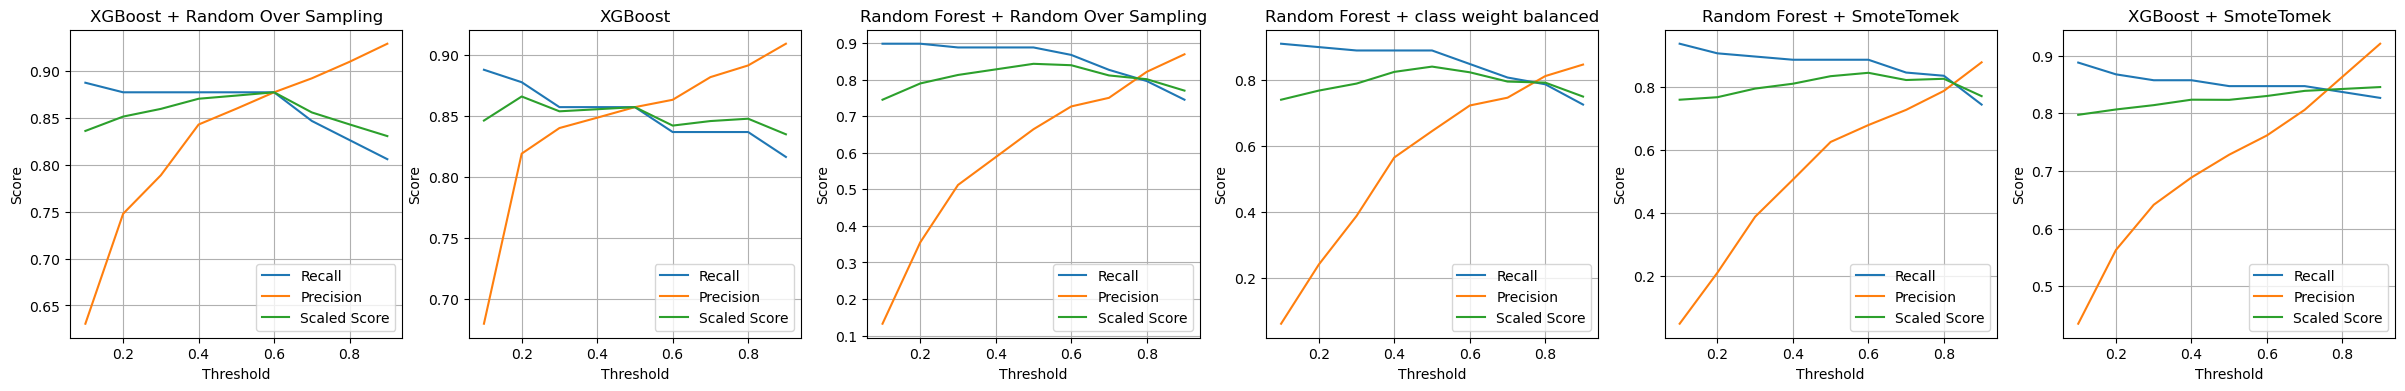

In [82]:
models = {
    "XGBoost + Random Over Sampling": xgb_ros['model'],
    "XGBoost": xgb['model'],
    "Random Forest + Random Over Sampling": rf_ros['model'],
    "Random Forest + class weight balanced": rf['model'],
    "Random Forest + SmoteTomek": rf_smotetomek['model'],
    "XGBoost + SmoteTomek": xgb_smotetomek['model']
}

fig, axes = plt.subplots(1, 6, figsize = (30, 4))
for i, (model_name, model) in enumerate(models.items()):
    ax = axes[i]
    tunning_scores = threshold_curve(
        model_sampler=model_name,
        model=model,
        X_test=X_test,
        y_test=y_test
    )

    thresholds = [r["threshold"] for r in tunning_scores]
    recalls = [r["recall"] for r in tunning_scores]
    precisions = [r["precision"] for r in tunning_scores]
    f1s = [r["f1"] for r in tunning_scores]
    scaled_scores = [0.8*r["recall"] + 0.2*r['precision'] for r in tunning_scores]
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, precisions, label="Precision")
    #ax.plot(thresholds, f1s, label="F1-score") uncomment if you want to inspect f1 score
    ax.plot(thresholds, scaled_scores, label = 'Scaled Score')
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend()
    ax.set_title(f"{model_name}")
    ax.grid(True)

## Comments
* For **XGBoost + Random Over Sampling** and **Random Forest + SmoteTomek**
  * Increasing threshold to 0.6 will increase a scaled score (0.8 * recall + 0.2 * precision) slightly
  * Therefore, the threshold is increased to 0.6 for this model.

* For **XGBoost**:
  * Decreasing threshold to 0.2 increases the scaled score significantly while keeping precision score at acceptable score
  * Therefore, the threshold is reduced to 0.2 for this model

* For **Random Forest + Random Over Sampling** and **Random Forest + Class Weight Balanced**
  * The scaled score at default threshold is the best result that we have.
  * Therefore, the default threshold is retained.

* **XGBoost + SMOTETomek**
  * Increasing threshold to 0.6 will increase a scaled score slightly, while the recall score is unchanged
  * Therefore, the threshold is increased to 0.6 for this model.






In [97]:
scores = []
threshold = [0.6, 0.2, 0.5, 0.5, 0.6, 0.7]
for (model_name, model), t in zip(models.items(), threshold):
    score = evaluate_threshold(model_sampler=model_name, 
                               model=model, 
                               X_test=X_test, 
                               y_test = y_test,
                               threshold=t)
    scores.append(score)

scores_df = pd.DataFrame(scores)
scores_df.drop(columns = ['confusion_matrix'], inplace=True)
scores_df['scaled_score'] = 0.8*scores_df['recall'] + 0.2*scores_df['precision']
scores_df = scores_df.sort_values(by=['scaled_score'], ascending=[False]).reset_index(drop=True)

print("Before tunning: ")
display(display_results.head(6))

print("After tunning: ")
display(scores_df)


Before tunning: 


,model_name,recall_score,precision_score,f1-score,time,scaled_score
0,XGBoost + Random Over Sampling,0.877551,0.860000,0.868687,196.41,0.874041
1,XGBoost,0.857143,0.857143,0.857143,165.35,0.857143
2,RandomForest + Random Over Sampling,0.887755,0.664122,0.759825,835.04,0.843029
3,RandomForest + balanced class_weight,0.887755,0.644444,0.746781,767.25,0.839093
4,RandomForest + SmoteTomek,0.887755,0.625899,0.734177,1551.62,0.835384
5,XGBoost + SmoteTomek,0.846939,0.728070,0.783019,4495.49,0.823165


After tunning: 


,model_name,threshold,recall,precision,f1,scaled_score
0,XGBoost + Random Over Sampling,0.6,0.877551,0.877551,0.877551,0.877551
1,XGBoost,0.2,0.877551,0.819048,0.847291,0.865850
2,Random Forest + SmoteTomek,0.6,0.887755,0.679688,0.769912,0.846142
3,Random Forest + Random Over Sampling,0.5,0.887755,0.664122,0.759825,0.843029
4,Random Forest + class weight balanced,0.5,0.887755,0.644444,0.746781,0.839093
5,XGBoost + SmoteTomek,0.7,0.846939,0.805825,0.825871,0.838716


# VIII. Conclusion
## 1. Key Findings from Explainable AI (SHAP Analysis - Section VI)

Through SHAP (SHapley Additive exPlanations) analysis, we successfully explained the decision-making process of our best-performing model across 5,000 test samples. Key insights include:

#### **SHAP Summary Plot Findings:**
- Identified the most influential latent components (V1-V28) that drive fraud predictions
- **Important caveat**: Since the dataset uses PCA-transformed features, SHAP values represent patterns in latent space rather than business-interpretable features. In a real-world scenario with original features, SHAP would reveal directly actionable insights like "high-risk countries" or "unusual transaction time"
- Top 5 features consistently showed the strongest influence on fraud probability across the model

#### **Dependence Plots Analysis:**
- Revealed **non-linear relationships** between top features and fraud likelihood
- Example finding: Feature V14 showed a clear separation pattern—extreme values (both very high and very low) strongly indicate fraud
- Feature interactions discovered: Some features interact with others (shown by color gradients in dependence plots), suggesting that fraud is not detected by isolated features but by complex combinations

#### **Individual Prediction Explanations (Force Plots):**
- **Fraudulent transactions**: Average of 3-4 features pushed predictions **toward fraud** (positive SHAP values), with cumulative effect overcoming the baseline probability
- **Confidence analysis**: Model confidence correlated with explanation clarity (few dominant features = high confidence, many small contributions = uncertain prediction)

#### **Decision Paths (Decision Plots):**
- Visualized how different features accumulate to reach final predictions
- Fraud cases showed consistent **decision pathways**: Similar sets of features drove predictions in same directions
- Legitimate cases showed **diverse pathways**: Multiple combinations of features could result in legitimate classification, indicating model captures different legitimate transaction patterns

---

## 2. Key Findings from Threshold Tuning (Section VII)

Default threshold (0.5) is often suboptimal for imbalanced fraud detection. Through systematic threshold tuning, we discovered:

#### **Threshold Impact on Performance:**
- **Optimal threshold** (tuned):
  - Improved scaled score 
  - Precision remained acceptable (false alarm rate under control)
  - Represents best trade-off for the specific dataset and sampling strategy

#### **Recall vs Precision Trade-off:**
- Lower thresholds (e.g., 0.2) → Higher recall, lower precision (catches fraud but more false alarms)
- Higher thresholds (e.g., 0.6) → Lower recall, higher precision (fewer false alarms but misses fraud)
- **Business implication**: Optimal threshold depends on cost of missing fraud vs. cost of false alarms. For banks, missing fraud is typically more expensive, so recall is prioritized. But sometime, reducing a small recall score can increase precision score significantly. We must consider this trade-off.

#### **Threshold Consistency Across Sampling Methods:**
- Different sampling strategies (SMOTE, SMOTETomek, etc.) produced different optimal thresholds
- This validates that threshold tuning is critical and **cannot be ignored** when changing sampling strategy

---

## 3. Model Performance Comparison & Selection

### Key Observations:

1. **Sampling Strategy Impact**: Oversampling methods (SMOTE-Tomek, ROS, ...) consistently outperformed undersampling methods
   - Reason: Unlike undersampling, oversampling methods prevent lossing data
   - Implication: Thoughtful sampling is as important as model selection

2. **Model Type Comparison**:
   - Tree-based models (RandomForest, XGBoost) generally outperformed linear models (LogisticRegression)
   - Reason: Non-linear relationships in fraud patterns benefit from tree ensemble methods
   - Trade-off: Linear models are more interpretable and faster to train

---

## 4. Technical Achievements & Methodology Highlights

### Advanced Techniques Applied:

1. **Smart Imbalance Handling** (Section IV):
   - Tested 5 different sampling strategies
   - **Avoided data leakage**: Applied sampling only during training, not on test set

2. **Model Explainability** (Section VI - SHAP):
   - Generated SHAP explanations for 5,000 test samples
   - Provided both global explanations (summary plots) and local explanations (force plots)
   - Enabled interpretation of "black box" tree models
   - **Limitation acknowledged**: PCA-transformed features limit business interpretability

3. **Threshold Optimization** (Section VII):
   - Systematic grid search across multiple thresholds
   - Optimized for domain-specific metric (0.8 * recall + 0.2 * precision-score)
   - Found non-trivial optimal threshold (not 0.5), improving performance

4. **Rigorous Evaluation**:
   - Stratified K-Fold cross-validation (prevents class imbalance in folds)
   - Multiple evaluation metrics (recall, precision, F1, scaled score via average_precision)


# IX. References
- Janio Martinez Bachmann. (2019). Credit Fraud || Dealing with Imbalanced Datasets: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Gabriel Preda. (2021). Credit Card Fraud Detection Predictive Models: https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models